# Apple Financial Dataset (1980-2026)



The Apple Comprehensive Financial Dataset contains detailed financial information about Apple Inc. from 1980 to 2026. The dataset includes quarterly summaries, with features such as revenue, net income, earnings per share, operating expenses, and other key financial metrics. This data is valuable for analyzing Apple’s financial performance over time and for building advanced machine learning models in areas such as time series forecasting, anomaly detection, and predictive financial analytics.

## First steps

### Libraries

In [ ]:
import pickle
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


import scipy.stats as stats

from sklearn.metrics import mean_squared_error, mean_absolute_error


### Load the data

Since we have downloaded the dataset locally, we will load it directly from our local CSV file containing Apple’s quarterly financial data.

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('data/aapl_stock_ml_features.csv', parse_dates=['date'])

Now, we are going to set he date column as the index of your DataFrame for three main reasons:

- **Strict Chronological Order**: By using the date as the index, we ensure the data is always in time order. In forecasting, the order of observations cannot be shuffled.

- **Time-Based Operations**: Pandas can perform moving window calculations (like moving averages) much more efficiently when the date is the index.

- **Seasonality Analysis**: Tools like seasonal_decompose need a time-based index to correctly detect yearly or quarterly patterns in the data.

In short, using the date as the index keeps the time series clean, efficient, and ready for analysis.

In [3]:
df.set_index('date', inplace=True)

# Display the first few rows of the DataFrame to verify it loaded correctly
df.head()

,open,high,low,close,volume,dividends,stock_splits,price_range,price_change,price_change_pct,...,target_direction,year,month,day,dayofweek,quarter,is_month_start,is_month_end,is_quarter_start,is_quarter_end
date,,,,,,,,,,,,,,,,,,,,,
1980-12-12,0.098389,0.098817,0.098389,0.098389,469033600,0.0,0.0,0.000428,0.000000,NaN,...,0,1980,12,12,4,4,0,0,0,0
1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,0.0,0.0,0.000428,-0.000428,-0.052171,...,0,1980,12,15,0,4,0,0,0,0
1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,0.0,0.0,0.000428,-0.000428,-0.073398,...,1,1980,12,16,1,4,0,0,0,0
1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,0.0,0.0,0.000428,0.000000,0.024750,...,1,1980,12,17,2,4,0,0,0,0
1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,0.0,0.0,0.000428,0.000000,0.028992,...,1,1980,12,18,3,4,0,0,0,0


### Data Cleaning

#### Null values

Before we start building models, it’s important to check for missing values in the dataset to ensure data quality.

In [4]:
null_counts = df.isna().sum()
columns_with_nulls = null_counts[null_counts > 0]

if not columns_with_nulls.empty:
    print("There are null values in the following columns:")
    print(columns_with_nulls)
else:
    print("No null values found. The dataset is clean.")

There are null values in the following columns:
price_change_pct      1
sma_5                 4
sma_10                9
sma_20               19
sma_50               49
sma_100              99
sma_200             199
volatility_5d         4
volatility_10d        9
volatility_20d       19
volatility_50d       49
rsi_14               13
bb_middle            19
bb_upper             19
bb_lower             19
bb_width             19
volume_sma_20        19
volume_ratio         19
return_1d             1
return_5d             5
return_10d           10
return_20d           20
return_60d           60
return_120d         120
return_252d         252
close_lag_1           1
volume_lag_1          1
close_lag_2           2
volume_lag_2          2
close_lag_3           3
volume_lag_3          3
close_lag_5           5
volume_lag_5          5
close_lag_10         10
volume_lag_10        10
target_return_1d      1
dtype: int64


What we are seeing is called the **“warm-up period”** of technical indicators. In time series theory, this has a very logical mathematical explanation related to lags and moving averages (MA).

This is happening because:
- **Moving Averages (SMA/EMA)**: A moving average depends on past values. For example, to calculate `sma_200` (the 200-day moving average), you need 200 previous days of data. That’s why the first 199 rows in the dataset are null: the model doesn’t yet have enough data to compute the average.

- **Lags**: When you create lagged features, like `close_lag_10`, the first row doesn’t have a value from 10 days ago because it’s the start of the series (December 12, 1980). That’s why the first 10 rows are null.

- **Returns**: For features like `return_252d` (annual return, since a trading year has 252 days), you need to compare today’s price with the price a year ago. This is why the first 252 rows are null.

In short, these initial nulls are perfectly normal—they reflect the fact that some indicators require a history of data to be computed.

As we have a large dataset (40 years), we will remove these initial rows. This, will not affect the model as it is a very small portion of the total history.

In [5]:
# Remove initial rows with missing values caused by warm-up periods
df_clean = df.dropna()

null_counts = df_clean.isna().sum()
columns_with_nulls = null_counts[null_counts > 0]

if not columns_with_nulls.empty:
    print("There are null values in the following columns:")
    print(columns_with_nulls)
else:
    print("No null values found. The dataset is clean.")
    
df = df_clean.copy()

No null values found. The dataset is clean.


#### Continuity (frequency) check

In a time series, we usually expect the data to be evenly spaced. However, the **stock market closes on weekends and holidays**, so some dates are missing.

By using `asfreq('B')`, we create a structure where every business day exists in the dataset. If a day is missing, like a holiday Monday, we fill it in so the series becomes continuous for all trading days.
This makes it much easier for us to calculate indicators, moving averages, or returns without worrying about missing dates breaking the calculations.

After creating a continuous time series, we may still have some missing values. To handle this, we use forward fill (`ffill`). This means that we replace any missing value with the **last available value before it**. For example, if the market was closed on a holiday, we carry forward the previous day’s closing price. We do this to maintain continuity in the time series, which is important for calculations like returns, moving averages, and other indicators.
 

In [6]:
# Ensure the frequency is set to business days and fill any missing dates with NaN
df_final = df_clean.asfreq('B')

# We use forward fill to fill any missing 'close' values, which is common in time series data to maintain continuity
df_final = df_final.ffill()

# Check the final dataset
print(f"Starting length: {len(df)}")
print(f"Final length of the series: {len(df_final)}")
print(f"Are there any null values in 'close'?: {df_final['close'].isna().sum()}")

Starting length: 11117
Final length of the series: 11510
Are there any null values in 'close'?: 0


We ensure that this have been done correctly.

In [7]:
#Check index differences to see which dates were added
added_dates = df_final.index.difference(df_clean.index)
print(f"There are {len(added_dates)} days that were filled (holidays/gaps).")

# Check the first few added dates
print("\nFirst 10 filled dates:")
print(added_dates[:10])

# Check a specific example in the DataFrame
if len(added_dates) > 0:
    example_date = added_dates[0]
    print(f"\nExample of the value in a filled date ({example_date}):")
    print(df_final.loc[example_date, ['open', 'high', 'low', 'close']])

There are 393 days that were filled (holidays/gaps).

First 10 filled dates:
DatetimeIndex(['1981-12-25', '1982-01-01', '1982-02-15', '1982-04-09',
               '1982-05-31', '1982-07-05', '1982-09-06', '1982-11-25',
               '1982-12-24', '1983-02-21'],
              dtype='datetime64[us]', name='date', freq=None)

Example of the value in a filled date (1981-12-25 00:00:00):
open     0.074862
high     0.075289
low      0.074862
close    0.074862
Name: 1981-12-25 00:00:00, dtype: float64


In [8]:
df = df_final.copy()

## Understanding the data

In this section, we are going to explore the columns of the dataset and inspect their contents. It is important to clearly understand the columns in order to know how to approach the problem.

In [10]:
df.head()

,open,high,low,close,volume,dividends,stock_splits,price_range,price_change,price_change_pct,...,target_direction,year,month,day,dayofweek,quarter,is_month_start,is_month_end,is_quarter_start,is_quarter_end
date,,,,,,,,,,,,,,,,,,,,,
1981-12-11,0.064595,0.065022,0.064167,0.064167,76092800.0,0.0,0.0,0.000856,-0.000428,-0.006622,...,0.0,1981.0,12.0,11.0,4.0,4.0,0.0,0.0,0.0,0.0
1981-12-14,0.062884,0.062884,0.062028,0.062028,25244800.0,0.0,0.0,0.000856,-0.000856,-0.033331,...,1.0,1981.0,12.0,14.0,0.0,4.0,0.0,0.0,0.0,0.0
1981-12-15,0.063739,0.064167,0.063739,0.063739,31315200.0,0.0,0.0,0.000428,0.000000,0.027584,...,1.0,1981.0,12.0,15.0,1.0,4.0,0.0,0.0,0.0,0.0
1981-12-16,0.066734,0.067162,0.066734,0.066734,65452800.0,0.0,0.0,0.000428,0.000000,0.046989,...,1.0,1981.0,12.0,16.0,2.0,4.0,0.0,0.0,0.0,0.0
1981-12-17,0.072295,0.072723,0.072295,0.072295,51452800.0,0.0,0.0,0.000428,0.000000,0.083328,...,1.0,1981.0,12.0,17.0,3.0,4.0,0.0,0.0,0.0,0.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11510 entries, 1981-12-11 to 2026-01-22
Freq: B
Data columns (total 64 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   open              11510 non-null  float64
 1   high              11510 non-null  float64
 2   low               11510 non-null  float64
 3   close             11510 non-null  float64
 4   volume            11510 non-null  float64
 5   dividends         11510 non-null  float64
 6   stock_splits      11510 non-null  float64
 7   price_range       11510 non-null  float64
 8   price_change      11510 non-null  float64
 9   price_change_pct  11510 non-null  float64
 10  sma_5             11510 non-null  float64
 11  ema_5             11510 non-null  float64
 12  sma_10            11510 non-null  float64
 13  ema_10            11510 non-null  float64
 14  sma_20            11510 non-null  float64
 15  ema_20            11510 non-null  float64
 16  sma_50            11510 no

In [12]:
print("There are " + str(len(df.columns)) + " columns in the DataFrame")
print("The columns are: " + ", ".join(df.columns))

There are 64 columns in the DataFrame
The columns are: open, high, low, close, volume, dividends, stock_splits, price_range, price_change, price_change_pct, sma_5, ema_5, sma_10, ema_10, sma_20, ema_20, sma_50, ema_50, sma_100, ema_100, sma_200, ema_200, volatility_5d, volatility_10d, volatility_20d, volatility_50d, rsi_14, macd, macd_signal, macd_histogram, bb_middle, bb_upper, bb_lower, bb_width, volume_sma_20, volume_ratio, return_1d, return_5d, return_10d, return_20d, return_60d, return_120d, return_252d, close_lag_1, volume_lag_1, close_lag_2, volume_lag_2, close_lag_3, volume_lag_3, close_lag_5, volume_lag_5, close_lag_10, volume_lag_10, target_return_1d, target_direction, year, month, day, dayofweek, quarter, is_month_start, is_month_end, is_quarter_start, is_quarter_end


Before we dive into the models, we need to understand what information we have. Our dataset contains the daily history of Apple Inc. (AAPL) from 1980 to 2024. We can group our columns into **five simple categories**:
- **The Core Price Data**: These columns tell us exactly what happened during the trading day:
    - **Open / Close**: The price at the beginning and the end of the day.
    - **High / Low**: The highest and lowest prices reached during the session.
    - **Volume**: How many shares were traded. High volume means a lot of activity.

- **The Lags**: In Time Series, the past is very useful.
    - **close_lag_1, lag_5...**: These columns show us the price from 1 day ago, 5 days ago, etc. We use these to see if yesterday's price helps us predict tomorrow's.

- **The Moving Averages**: Stock prices are "noisy" (they jump up and down constantly).
    - **SMA (Simple Moving Average)**: This is the average price over a period (like 50 or 200 days). We use this to "smooth" the chart and see the long-term direction of the market, ignoring the small daily noise.

- **The "Market Thermometer" (Technical Indicators)**: These tell us about the "mood" of the investors:
    - **RSI (Relative Strength Index)**: Tells us if the stock is "too hot" (overbought) or "too cold" (oversold).
    - **Volatility**: Measures how "crazy" or "calm" the price swings are.

- **Time Features**: Markets often behave differently depending on the date.
    - **Month, Quarter, DayOfWeek**: We use these to find "seasonal" patterns. For example, does Apple always go up before Christmas or after a new iPhone launch?


Before we dive into the models, we need to understand what information we have. Our dataset contains the daily history of Apple Inc. (AAPL) from 1980 to 2024. We can group our columns into **five simple categories**:
- **The Core Price Data**: These columns tell us exactly what happened during the trading day:
    - **Open / Close**: The price at the beginning and the end of the day.
    - **High / Low**: The highest and lowest prices reached during the session.
    - **Volume**: How many shares were traded. High volume means a lot of activity.

- **The Lags**: In Time Series, the past is very useful.
    - **close_lag_1, lag_5...**: These columns show us the price from 1 day ago, 5 days ago, etc. We use these to see if yesterday's price helps us predict tomorrow's.

- **The Moving Averages**: Stock prices are "noisy" (they jump up and down constantly).
    - **SMA (Simple Moving Average)**: This is the average price over a period (like 50 or 200 days). We use this to "smooth" the chart and see the long-term direction of the market, ignoring the small daily noise.

- **The "Market Thermometer" (Technical Indicators)**: These tell us about the "mood" of the investors:
    - **RSI (Relative Strength Index)**: Tells us if the stock is "too hot" (overbought) or "too cold" (oversold).
    - **Volatility**: Measures how "crazy" or "calm" the price swings are.

- **Time Features**: Markets often behave differently depending on the date.
    - **Month, Quarter, DayOfWeek**: We use these to find "seasonal" patterns. For example, does Apple always go up before Christmas or after a new iPhone launch?


### Exploratory Data Analysis

In this section we are going to get insights about the dataset. These will be very useful to know more about the data and to select the best way to go ahead with the problem.

#### Historical Price Trend

The first look to get basic insights can be at the "Close" price over the last 40 years.

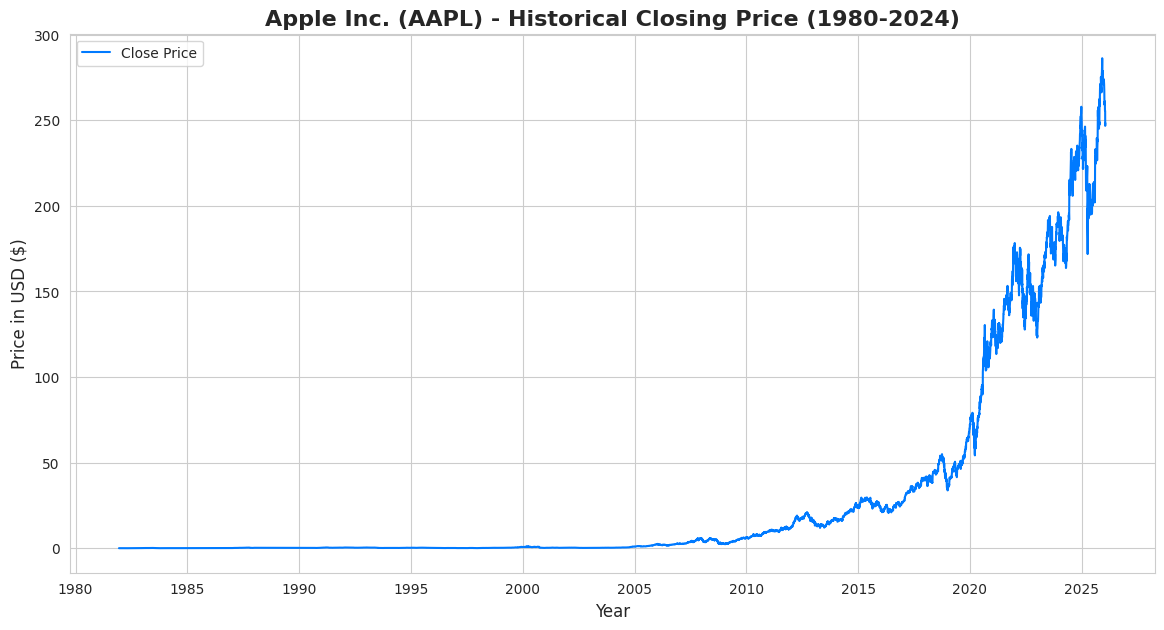

In [14]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Draw the line plot for the closing price
plt.plot(df.index, df['close'], color='#007AFF', linewidth=1.5, label='Close Price')

# Add details
plt.title('Apple Inc. (AAPL) - Historical Closing Price (1980-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price in USD ($)', fontsize=12)
plt.legend(loc='upper left')

plt.show()

Just by looking at the chart of Apple's closing price, we can notice several key things:
- **A Massive Long-Term Trend**: The price doesn't stay around a fixed value. From 1980 to roughly 2010, it looks almost flat, but then it "takes off." In a stable (stationary) world, the price would bounce around a center line. Here, the "center" is clearly moving up. Taking this into account, we could say that **this series has a trend**.

- **Changing Volatility**: The price movements in the 80s and 90s are tiny, but in the last 5 years, the vertical jumps are huge. With this, we could say that the variance o the data is not constant, it increases as the price grows.

So, looking at this plot, we can visually confirm that Apple's stock price is **non-stationary**. The mean of the data is clearly increasing over time (upward trend), and the fluctuations are becoming larger (changing variance). In time series terms, the series 'drifts' away from its starting point instead of returning to a constant average.

#### Seasonal Decomposition Analysis

To understand Apple's price, we separate it into four distinct parts. This process helps us see the "hidden" patterns inside the data.

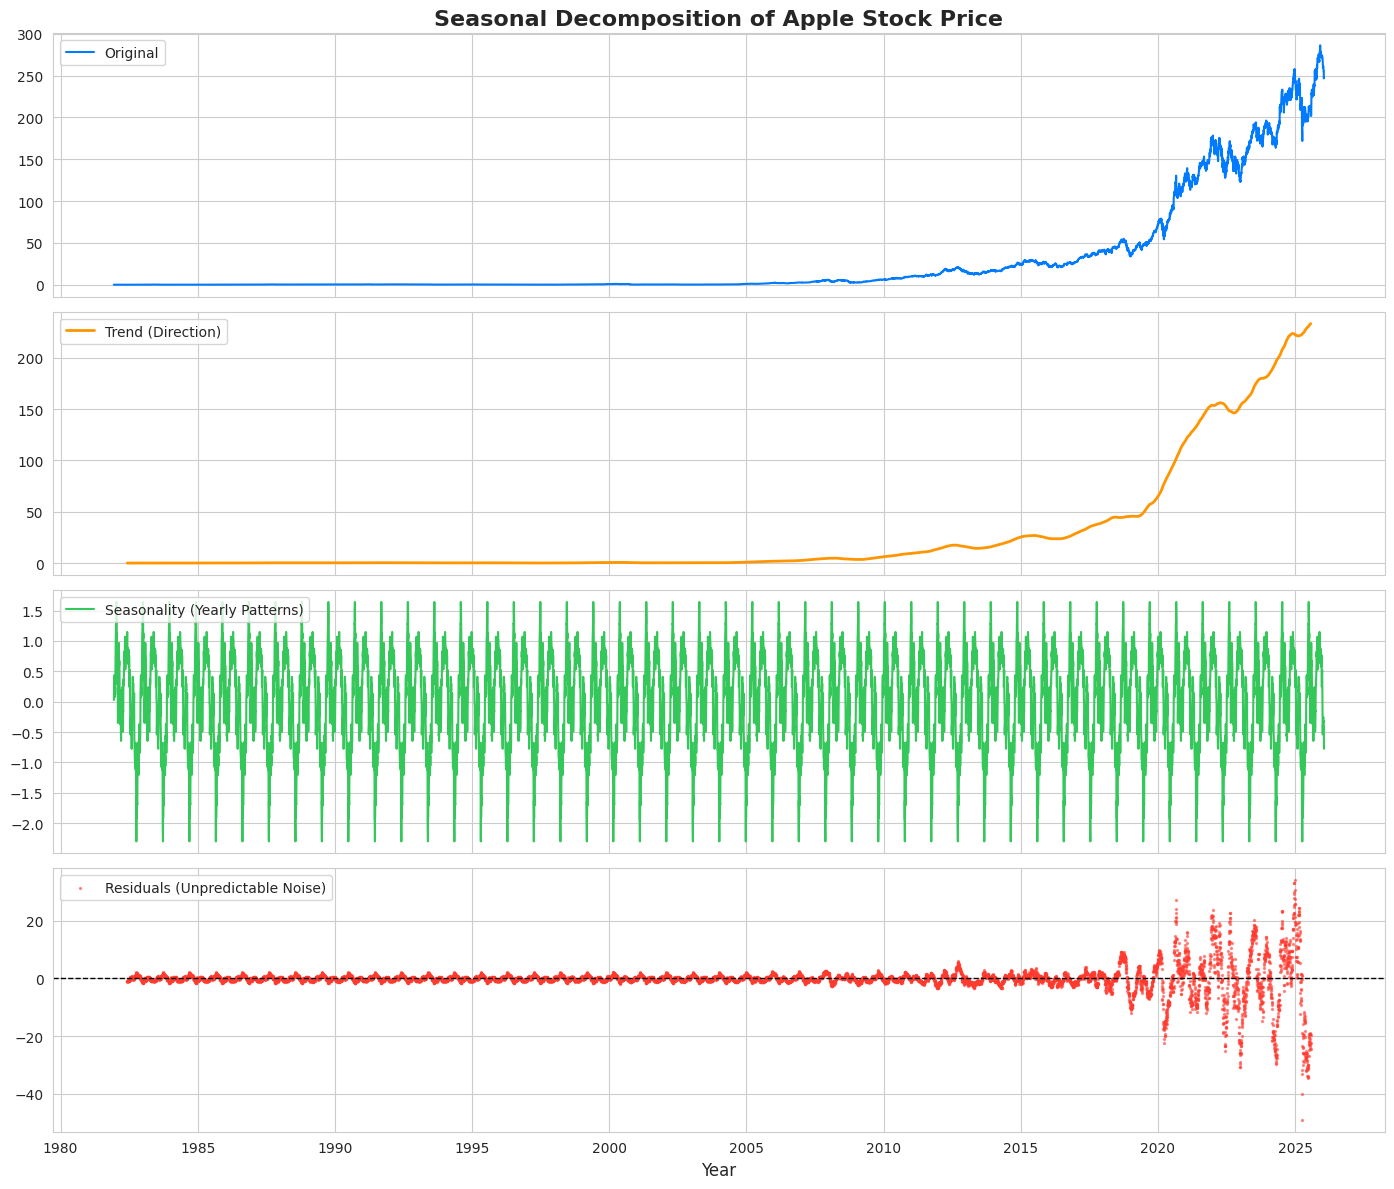

In [15]:
# Calculate the decomposition of the time series
# We use a period of 252 to capture the yearly seasonality (number of trading days in a year)
decomposition = seasonal_decompose(df['close'], model='additive', period=252)

# Extract each component
trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid


# Configure the subplots for the decomposition
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Plot 1:: Original Series
axes[0].plot(df['close'], label='Original', color='#007AFF')
axes[0].set_title('Seasonal Decomposition of Apple Stock Price', fontsize=16, fontweight='bold')
axes[0].legend(loc='upper left')

# Plot 2: Trend
axes[1].plot(trend, label='Trend (Direction)', color='#FF9500', linewidth=2)
axes[1].legend(loc='upper left')

# Plot 3: Seasonality
axes[2].plot(seasonal, label='Seasonality (Yearly Patterns)', color='#34C759')
axes[2].legend(loc='upper left')

# Plot 4: Residuals
axes[3].scatter(df.index, resid, label='Residuals (Unpredictable Noise)', color='#FF3B30', s=2, alpha=0.5)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].legend(loc='upper left')

# Last details
plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

- **Observed**: This is the raw data, the actual closing price of Apple. We can see a "messy" line that stays flat for a long time and then grows after 2010. With this plot, is very hard to predict the price directly from this chart because it contains too much information at once.

- **Trend**: By removing the noise, we can see the "true" path of the stock. We see a smooth continuous upward curve. This confirms that the mean (average) price is always changing. This means the series is **Non-Stationary**. Apple is a "growth" company, and that growth is the main force moving the price.

- **Seasonal**: This part shows patterns that repeat every year (like a "heartbeat"). In the left axis, the values go ffrom -2.0 to +1.5. This means that jus because of the time of the year (like December vs. July, for example), the price usually changes by only $1 or $2. Since the total price of Apple is around $200, a change of $2 is tiny (only 1%). This tells us that while a "seasonal" pattern exists, it is not the reason Apple is expensive. The trend is much more important than the season.

- **Residuals**: It is what’s left after we take away the Trend and the Seasonality. We cam see random dots around the center line. However, after the year 2020, the dots become much larger and more spread out. This shows that volatility has increased. Unexpected events (like global news or economic crises) are hitting the price harder now than they did in the 90s. This makes our future predictions more challenging.

#### Rolling Statistics

To confirm our suspicions about stationarity, we calculate the Rolling Mean and Rolling Standard Deviation using a window of 252 days (one business year).

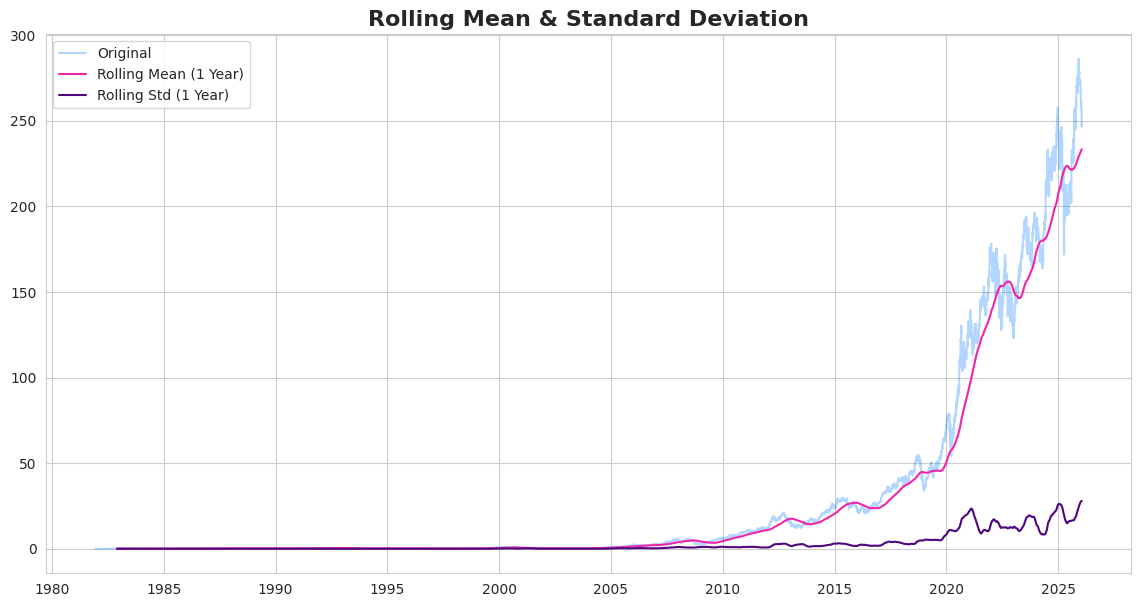

In [17]:
# Calculate rolling mean and standard deviation with a window of 252 (1 year)
rolling_mean = df['close'].rolling(window=252).mean()
rolling_std = df['close'].rolling(window=252).std()

plt.figure(figsize=(14, 7))
plt.plot(df['close'], color='#007AFF', alpha=0.3, label='Original')
plt.plot(rolling_mean, color="#EE26AB", label='Rolling Mean (1 Year)')
plt.plot(rolling_std, color="#500581", label='Rolling Std (1 Year)')

plt.title('Rolling Mean & Standard Deviation', fontsize=16, fontweight='bold')
plt.legend(loc='best')
plt.show()

- **The Rolling Mean (Pink Line)**: In a stable (stationary) world, this line should be flat. However, the red line is constantly climbing. This tells us that the "average" price of Apple depends on when you look at it. It was low in 2000 and high in 2024. This confirms that the mean is not constant.

- **The Rolling Standard Deviation (Purple Line)**: This measures the "risk" or how much the price jumps. This line is also moving up. The price swings are much larger now than they were 20 years ago. So, the variance is not constant.

Based on the Decomposition and these Rolling Statistics, we have clear visual proof: Apple's stock price is Non-Stationary. It has a strong trend and changing volatility. This means we cannot use this raw data for an ARIMA model yet. We need to transform it first.

#### Price Distribution

In this plot, we are looking at the distribution of Apple's closing prices to see if they follow a Normal Distribution.

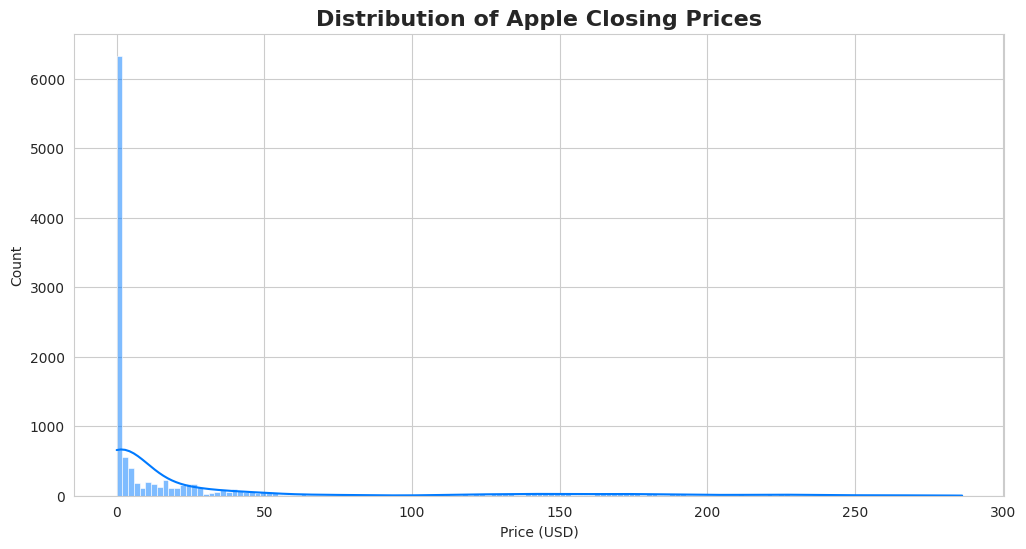

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(df['close'], kde=True, color="#007AFF")
plt.title('Distribution of Apple Closing Prices', fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)')
plt.show()

- **The Shape**: Instead of a symmetric bell, we see that most of the data is gathered on the left side (low prices), with a very long "tail" stretching to the right. It happens because Apple spent many years at low prices (under $50) and only recently reached very high values ($150-$200).

- **The Density**: The smooth blue line shows that our data is not "normally distributed." This is important to take into account because standard statistical models often work better when data is normal. The fact that our distribution is so skewed is another sign that the raw price is difficult to model without transformations.

#### ACF & PACF Analysis

We can also analyze the correlation of the stock price with its own past values (lags).

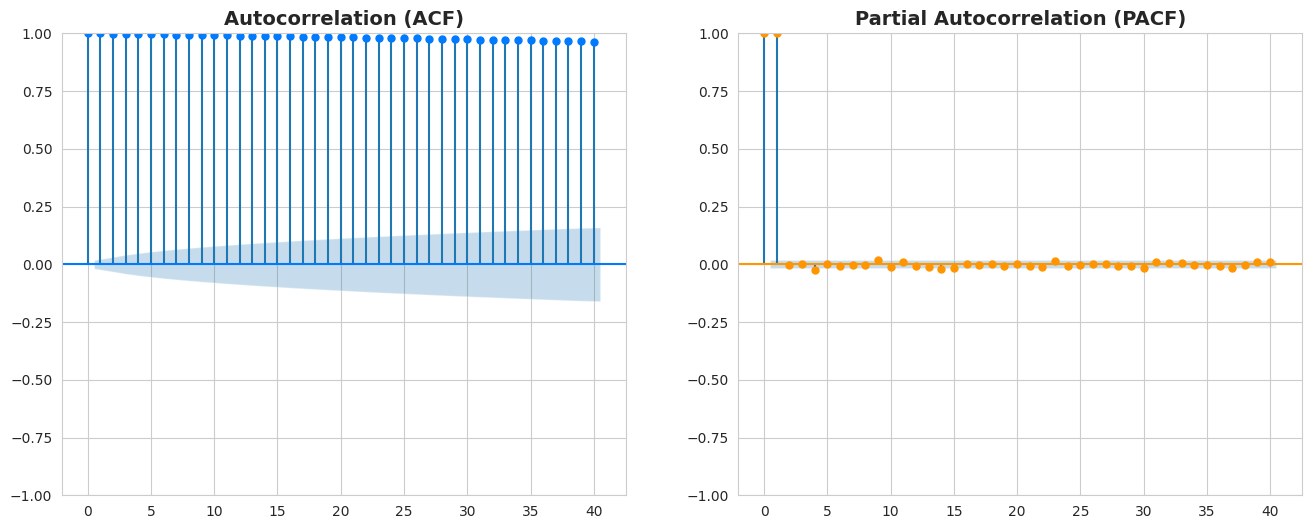

In [20]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Autocorrelation (ACF)
plot_acf(df['close'], lags=40, ax=ax1, color='#007AFF')
ax1.set_title('Autocorrelation (ACF)', fontsize=14, fontweight='bold')

# Partial Autocorrelation (PACF)
plot_pacf(df['close'], lags=40, ax=ax2, color='#FF9500')
ax2.set_title('Partial Autocorrelation (PACF)', fontsize=14, fontweight='bold')

plt.show()

- **Autocorrelation (ACF)**: The blue bars start very high and decay extremely slowly. Even after 40 days (lags), the correlation is still very strong. It shows that the price has a strong "memory" or trend. In a stationary series, these bars would drop to zero very quickly (another confirmation of non-stationary series).

- **Partial Autocorrelation (PACF)**: There is one huge peak at Lag 1 (yesterday's price), and then all other peaks are almost zero or inside the blue shaded area (the "noise" zone). This tells us that the price of today is almost entirely explained by the price of yesterday. All the other previous days don't add much new information once we know yesterday's value. This pattern is typical of a Random Walk.

The ACF and PACF plots provide the final evidence we needed. The slow decay in the ACF confirms that Apple's stock price is non-stationary and dominated by a trend. The sharp drop in the PACF after the first lag suggests that the most recent price is the strongest predictor. To proceed with an ARIMA model, we must now transform the series into its stationary version by calculating the daily returns (First Differencing).

#### Daily Returns (First Difference)

In this step, we are looking at the "Total Price" and started looking at the "Daily Change" (how much the price moves each day). This is called First Differencing ($d=1$).

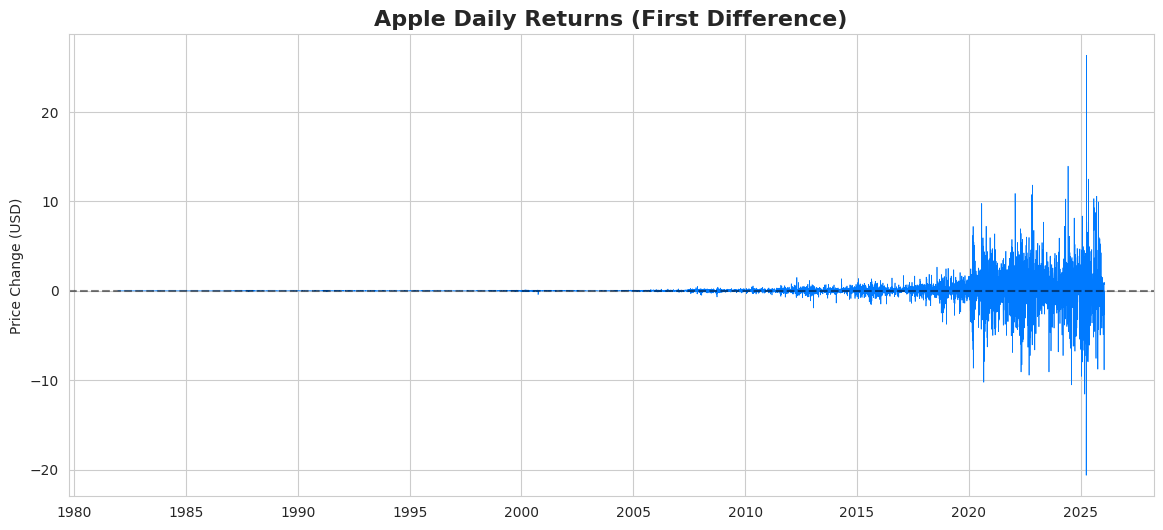

In [24]:
# Calculate the first difference (returns) of the closing price
df['returns'] = df['close'].diff()
# Remove the first row which will have NaN due to differencing
# so that we can analyze the returns without issues
df.dropna(inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(df['returns'], color='#007AFF', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Apple Daily Returns (First Difference)', fontsize=16, fontweight='bold')
plt.ylabel('Price Change (USD)')
plt.show()

- **The "Flat" Effect (Stationarity)**: The upward "ramp" is gone. Now, the data vibrates around the zero line. This means the mean (average) is finally constant. We have successfully removed the trend. This is the first requirement to start an ARIMA model.

- **The "Volatility" Spikes (2020-2024)**: The vertical lines (spikes) are much longer at the end of the graph than at the beginning. This is happening beacuse:
    - **Price Scale**: In 1990, Apple cost $1. A 5% move was only $0.05. In 2024, Apple costs $200. The same 5% move is now $10. That is why the lines look "bigger", it is just a matter of proportion.
    - **Market Shocks**: Events like the 2020 Pandemic caused investors to react more aggressively, creating larger jumps in price.

By calculating the Daily Returns, we transformed the price into a stationary series. The data now fluctuates around zero, proving that the trend has been removed. The larger spikes seen after 2020 are mainly due to the higher price of the stock and increased market uncertainty. This 'flat' version of the data is what we will can use to train our ARIMA model.

##### Percentage Returns

As we saw in the initial plots, Apple's Close price is a Random Walk. It has a strong upward trend, meaning its mean and variance change over time. This makes it "Non-Stationary," and an ARIMA model cannot make reliable predictions on this type of data.

To fix this, we can calculate the percentage_change. This process is a form of Differencing. Instead of looking at the absolute price, we look at the **daily change**. This normalization removes the "Price Effect" and allows us to compare different decades fairly.

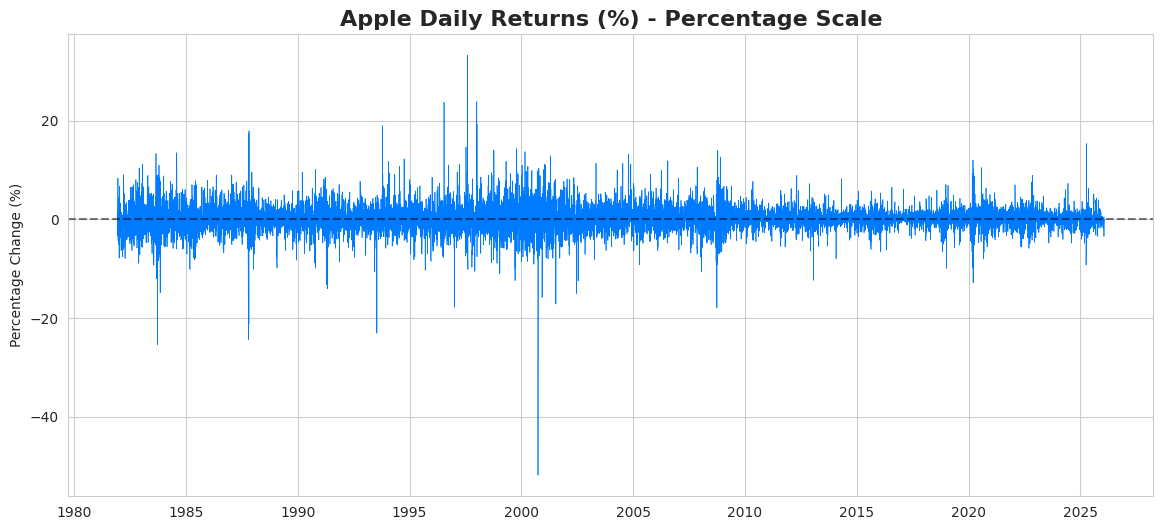

In [18]:
# Calculate percentage change (returns in percentage)
df['percentage_change'] = df['close'].pct_change() * 100

plt.figure(figsize=(14, 6))
plt.plot(df['percentage_change'], color='#007AFF', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Apple Daily Returns (%) - Percentage Scale', fontsize=16, fontweight='bold')
plt.ylabel('Percentage Change (%)')
plt.show()

- **The Reality of Volatility**: When looking at percentages (%), the spikes in 1987, 2000, and 2008 are just as large (or larger) than the spikes in 2020. The huge jumps we saw in the previous plot (in dollars) were just an optical illusion caused by the high stock price. In relative terms, Apple's risk has been consistent over time.

- **The "Crash" of 1987**: Notice that giant drop near the start of the graph. That is the 1987 market crash. In the "dollar" plot (previous one), it looked like a tiny dot. Here, it shows its true face: a massive percentage drop.

- **Massive pikes in 1998-1999**: If we look at the Percentage Plot, we see giant jumps during these years. This happened for two main reasons:
    - **The Return of Steve Jobs**: After being away for years, Steve Jobs returned to lead Apple. He launched the iMac G3 (the famous colorful computer). It was a huge success that saved Apple from bankruptcy (running out of money).
    - **The Dot-com Bubble**: In the late 90s, investors were extremely excited about technology companies. Everyone was buying tech stocks, causing prices to "rocket" upward.

- **Massive drop in 2000-2001**: Just after the big rise, we see one of the largest downward spikes in the entire history of Apple. This was caused by two major hits:
    - **The Dot-com Crash**: The "tech bubble" finally burst. Investors realized that many technology companies were overvalued. They panicked and started selling everything. Apple, being a tech star, was hit very hard.
    - **The 2001 Recession**: The economy slowed down globally. People stopped buying expensive computers like the new Macs, and Apple's profits dropped significantly.

This version of the data is much more "balanced." Modeling percentage changes (or Log-Returns) is usually more accurate because it **treats a 5% gain in 1990 the same as a 5% gain today**.

##### Percentage Returns Decomposition Analysis

To check that this calculated percentage is a stacionary series, we can follow the decomposition analysis.

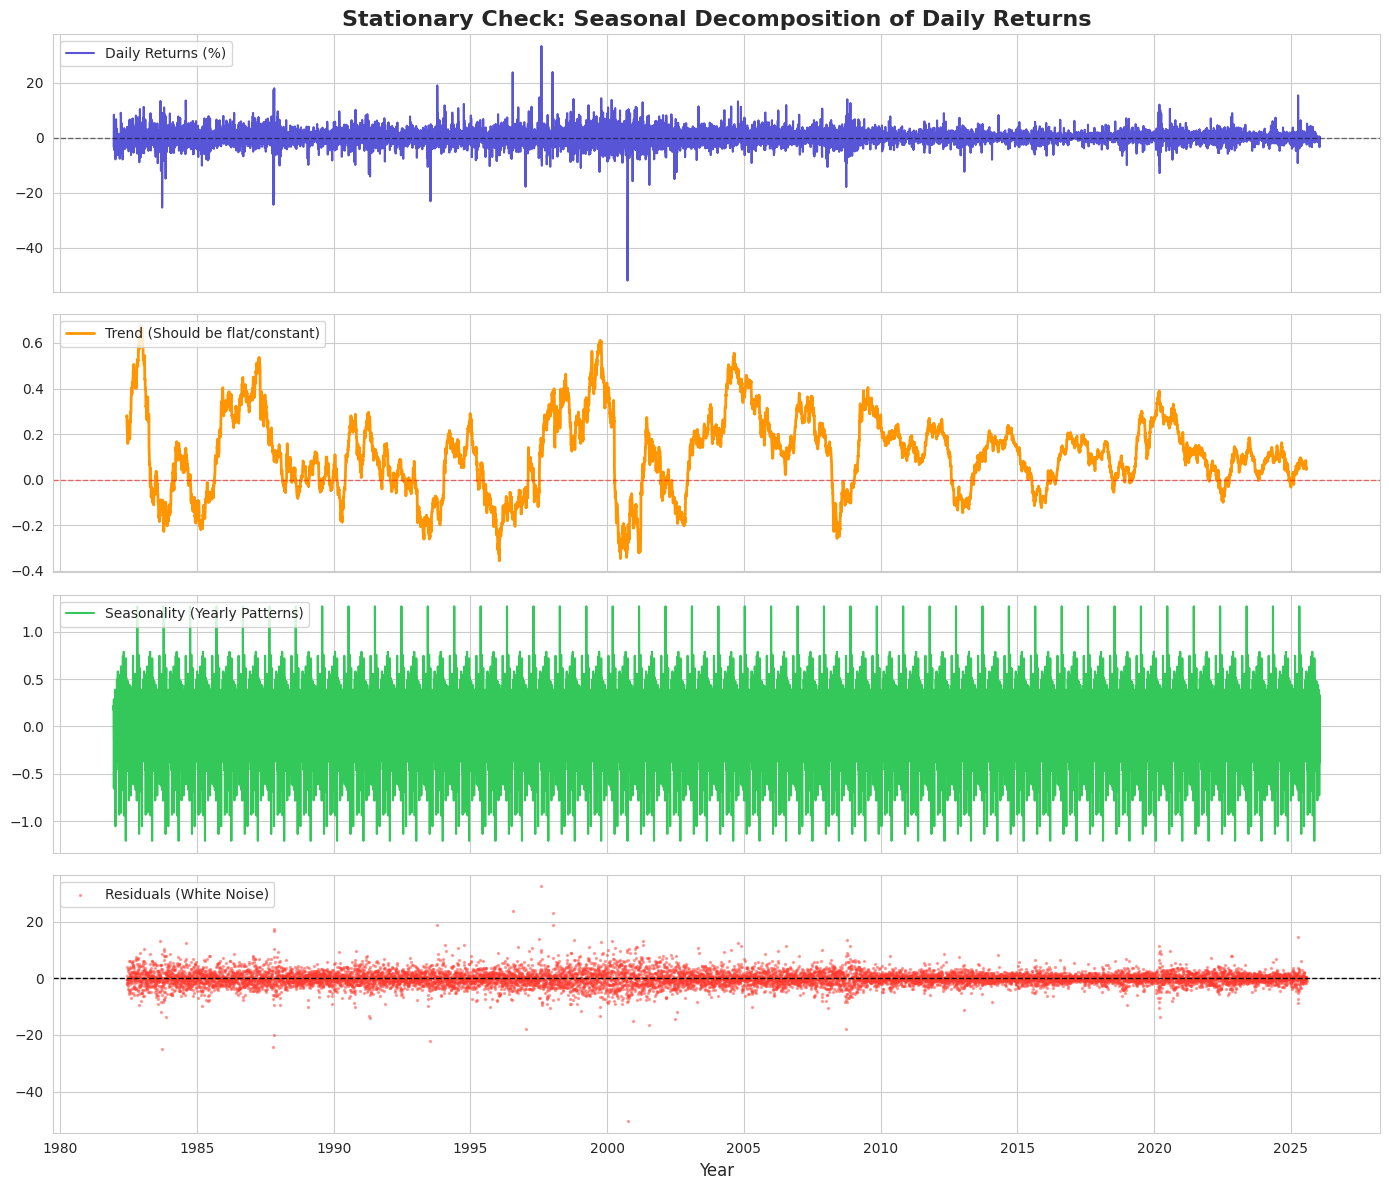

In [19]:
df_returns = df['percentage_change'].dropna()

# Use 252 to capture yearly seasonality in returns
decomposition_ret = seasonal_decompose(df_returns, model='additive', period=252)

# Extract components
trend_ret = decomposition_ret.trend
seasonal_ret = decomposition_ret.seasonal
resid_ret = decomposition_ret.resid

# Configure the subplots for the decomposition of returns
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Plot 1: Return series (original)
axes[0].plot(df_returns, label='Daily Returns (%)', color='#5856D6') # Color púrpura para diferenciar
axes[0].set_title('Stationary Check: Seasonal Decomposition of Daily Returns', fontsize=16, fontweight='bold')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].legend(loc='upper left')

# Plot 2: Trend (should be flat/constant)
axes[1].plot(trend_ret, label='Trend (Should be flat/constant)', color='#FF9500', linewidth=2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5) # Referencia en 0
axes[1].legend(loc='upper left')

# Plot 3: Seasonality (yearly patterns)
axes[2].plot(seasonal_ret, label='Seasonality (Yearly Patterns)', color='#34C759')
axes[2].legend(loc='upper left')

# Plot 4: Residuals (should look like white noise)
axes[3].scatter(df_returns.index, resid_ret, label='Residuals (White Noise)', color='#FF3B30', s=2, alpha=0.4)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].legend(loc='upper left')

plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

- **Observed (Daily Returns %)**: This is our transformed data. Instead of showing the price in dollars, it shows the percentage change each day. We can see how the line now stays around the zero horizontal axis for the entire 40-year history. This "flat" appearance is exactly what we need a series that doesn't "explode" or drift away.

- **Trend (The Flat Mean)**: This is the most important plot for our model. Unlike the price trend (which was a huge upward curve), this trend is a flat line near 0%. While it has tiny micro-fluctuations (between -0.4% and 0.6%), it always returns to the center. This confirms **the series is Stationary** the average return doesn't change over decades, even if the stock price does.

- **Seasonal**: Similar to the price plot, we see a repeating annual pattern. However, here it is measured in percentages. It shows that certain times of the year consistently add or subtract a tiny fraction of a percent to the daily move. Since it is constant and predictable, the ARIMA model can easily factor this in.

- **Residuals**: This represents the unpredictable news. We can see that, unlike the price residuals, these dots don't necessarily get "larger" at the end of the graph in a massive way. The spikes in 1987 or 2000 are just as visible as the ones in 2020. This proves that relative risk (percentage drop) has been a part of Apple's DNA since the beginning.

Comparing this decomposition with the previous one (Price), the difference is clear. **We have successfully stripped away the Non-Stationary Trend**, leaving us with a stable, mean-reverting signal. This confirms that modeling Percentage Changes is the mathematically correct path for our ARIMA forecast.1

#### QQ-Plot (Distribution Analysis)

The QQ-Plot compares our returns to a perfect Normal Distribution (the red line).

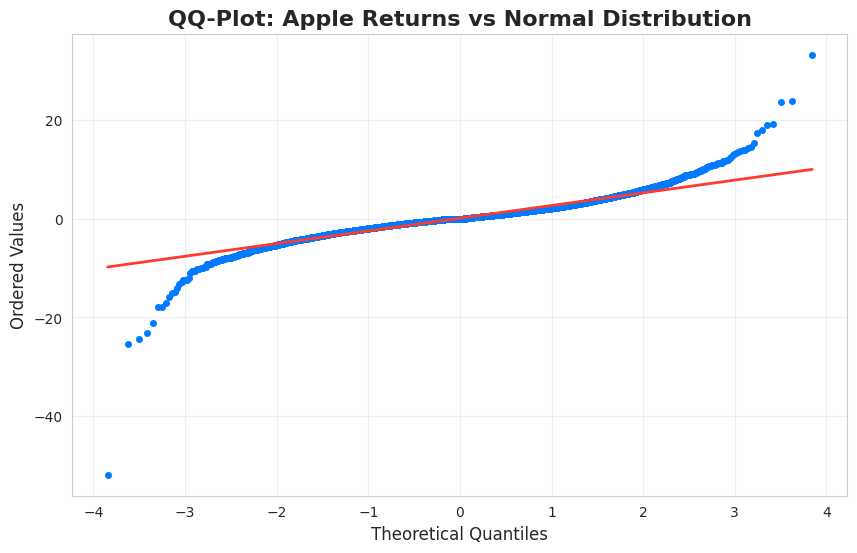

In [20]:
plt.figure(figsize=(10, 6))

# Generate the data for the QQ-Plot
stats.probplot(df['percentage_change'].dropna(), dist="norm", plot=plt)


# Line 0: Dots (data)
# Line 1: Straight line (theory)
ax = plt.gca()
ax.get_lines()[0].set_markerfacecolor('#007AFF')
ax.get_lines()[0].set_markeredgecolor('#007AFF')
ax.get_lines()[0].set_markersize(4)

ax.get_lines()[1].set_color('#FF3B30') # Red line for the theoretical quantiles
ax.get_lines()[1].set_linewidth(2)

plt.title('QQ-Plot: Apple Returns vs Normal Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

- **The Center**: In the middle of the graph, the blue dots follow the red line quite well. This means that for "normal" days, Apple's returns are somewhat predictable.

- **The Tails (Extremes)**: At both ends, the blue dots drift away from the line significantly. This confirms that Apple has "Fat Tails". In simple terms, extreme events (like a -10% or +10% day) happen much more often than standard statistics would suggest. Since ARIMA assumes a normal distribution of errors, it will likely be very good at predicting "average" days but will under-predict the size of major crashes or spikes.

The QQ-Plot reveals that Apple’s returns are not perfectly normal. While the center follows the theoretical line, the heavy tails indicate that extreme market shocks are frequent. This is a classic characteristic of financial time series known as 'Fat Tails,' and it's a vital piece of information for our risk assessment.

#### Analysis of Trading Volume

Volume represents the total number of shares traded daily. It measures the 'conviction' of the market: high volume confirms that a price movement is backed by many investors.

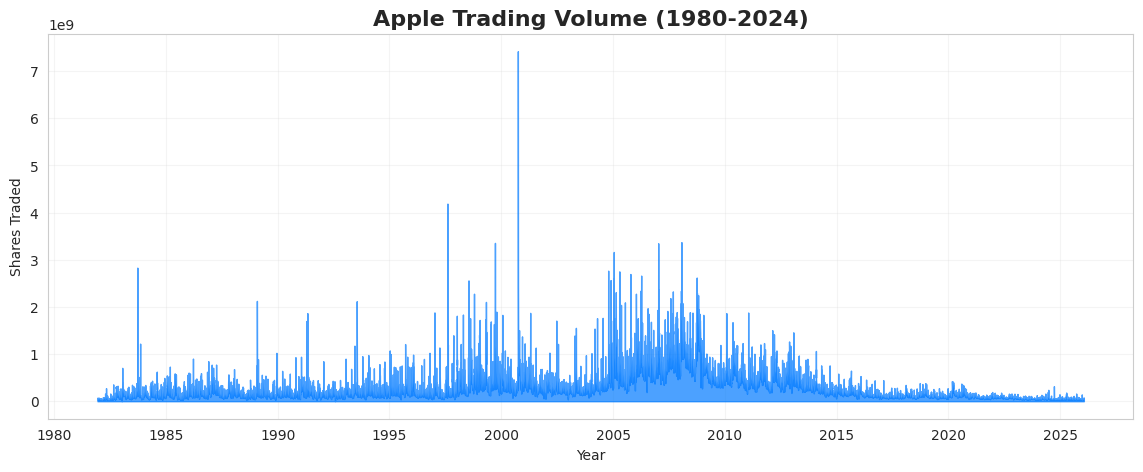

In [21]:
plt.figure(figsize=(14, 5))

plt.fill_between(df.index, df['volume'], color='#007AFF', alpha=0.7)

plt.title('Apple Trading Volume (1980-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Shares Traded')
plt.xlabel('Year')
plt.grid(True, alpha=0.2)
plt.show()

Although recent years show a higher baseline of volume, the frequency of spikes was much higher before the year 2015.
- **The Volatile Era (1980-2000)**: During these decades, Apple was a highly speculative stock. Every news (like the return of Steve Jobs or the launch of the iMac) triggered massive reactions, creating frequent spikes of euphoria and panic.

- **The Mature Era (2015-Present)**: Today, Apple is a global leader. While the total number of shares traded is much larger, the activity is more stable. We see fewer spikes because the company is no longer fighting for survival, but rather seen as a steady institutional investment.

This plot confirms that the price movements we saw in our previous 'Returns' analysis were real and significant, especially during the chaotic early years of the company."

#### Volatility vs. Volume: Analyzing Market Panic

This scatter plot reveals the relationship between price changes (Volatility) and market activity (Volume).
- **Volume**: Measures the total number of shares traded. High volume means many participants are in agreement that something important is happening.
- **Volatility**: Measures the rate and magnitude of price changes. It indicates risk and uncertainty.

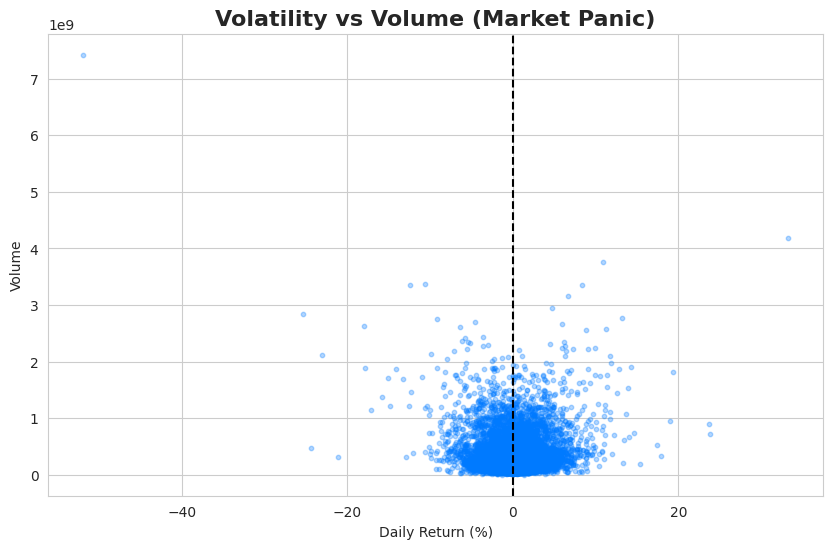

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(df['percentage_change'], df['volume'], alpha=0.3, color='#007AFF', s=10)
plt.title('Volatility vs Volume (Market Panic)', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Volume')
plt.axvline(0, color='black', linestyle='--')
plt.show()

- **Volatility**: We can observe a 'V' shape. This indicates that extreme returns (positive or negative) are accompanied by significantly higher trading volume. Investors stay quiet when the price is stable but rush to trade during big moves.

- **Asymmetric Panic**: The highest volume points are often found on the negative side (left). This confirms that 'Panic Selling' is a more powerful driver of volume than 'Euphoric Buying.' Large price drops trigger massive liquidations.

- **Outliers**: The distant points on the far left and right represent historical market shocks. This plot proves that our 'Fat Tails' (from the QQ-Plot) are directly linked to these massive surges in trading activity.

As seen in our scatter plot, volatility and volume are positively correlated. Extreme price swings (high volatility) act as a magnet for high volume, as investors react to news with either fear or greed. In contrast, stable prices (low volatility) usually see lower trading activity."

#### Stability vs. Extreme Risk

We present two versions of the returns distribution to capture the full statistical profile of Apple:

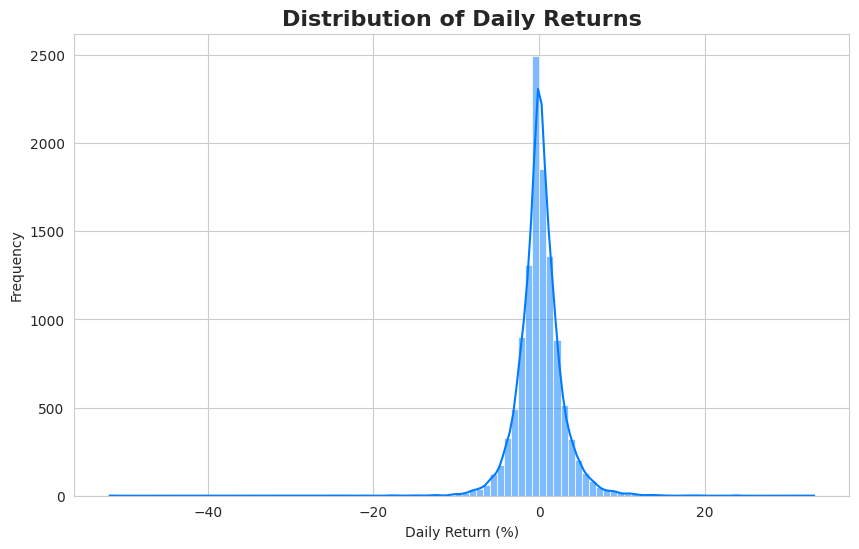

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['percentage_change'].dropna(), kde=True, color='#007AFF', bins=100)
plt.title('Distribution of Daily Returns', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

This plot shows that while Apple is usually stable, it has experienced "earthquake" days. There were moments in history where the stock jumped or crashed by 20%, 30%, or even more. These events are rare, but they do happen.

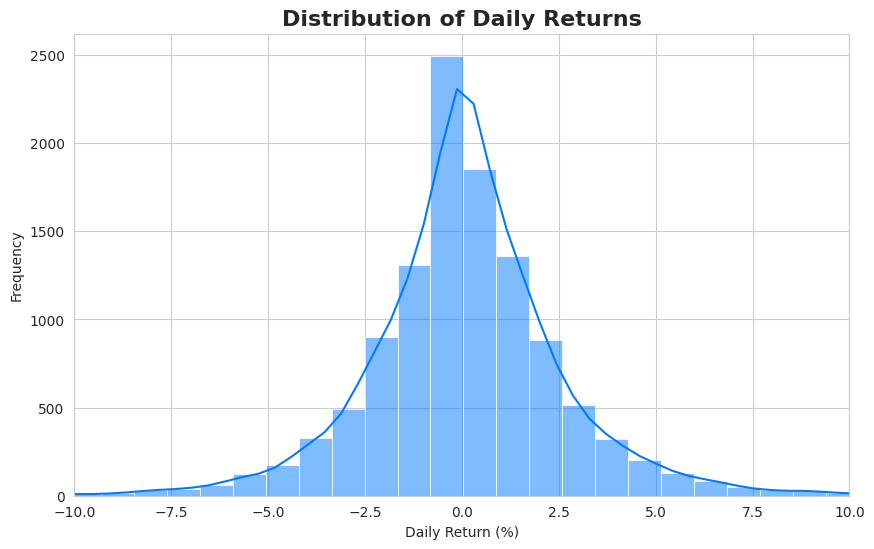

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['percentage_change'].dropna(), kde=True, color='#007AFF', bins=100)
plt.title('Distribution of Daily Returns', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.xlim(-10, 10) # Limit x-axis to focus on the central part of the distribution
plt.show()

This other plot shows that 99% of the time, Apple is very predictable. On most days, the stock price barely moves (remaining close to 0%).

Taking these two plots into account we can have some hypothesis:
- **The model will be good for "normal days" but bad for "crises"**: Since most data points are in the center, the model will learn to predict normal days very well. However, it will not be able to predict a massive crash or a huge spike.

- **Confirmation of Stationarity**: The fact that the data clusters around 0% in both plots is visual proof that we did a great job. The ARIMA model will work mathematically with this returns. If we had used the raw price (with its trend), the model would have failed completely.

#### Seasonality Check 

This boxplot breaks down Apple's daily returns by month to identify seasonal trends.

/tmp/ipykernel_6800/3028882105.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='percentage_change', data=df, palette='Blues')


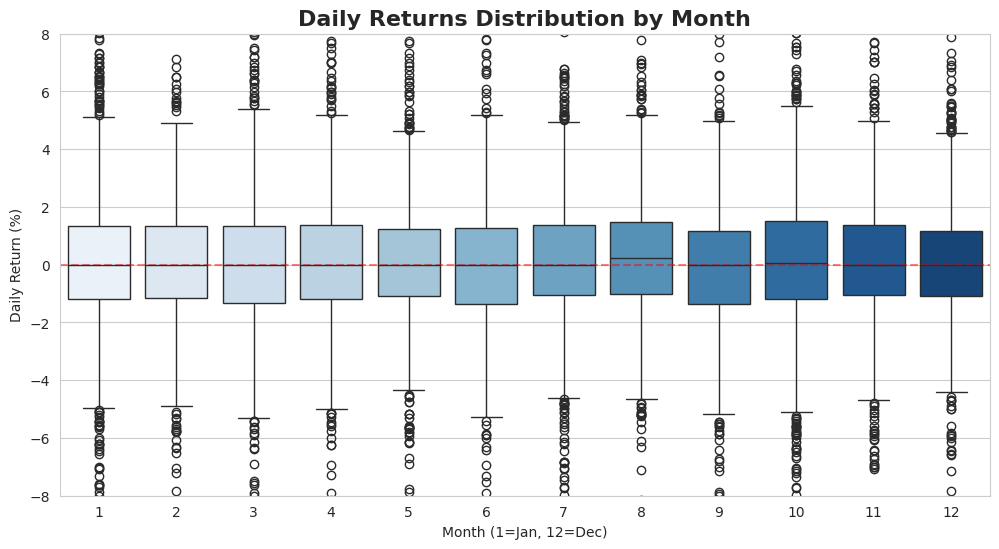

In [25]:
# Extraemos el mes de la fecha
df['month'] = df.index.month

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='percentage_change', data=df, palette='Blues')
plt.title('Daily Returns Distribution by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.ylim(-8, 8) # Centramos en los datos más comunes
plt.show()

- **High Volatility in October**: If we look at month 10 (October), it has the largest "box" and the longest "whiskers." This is because October is historically the most volatile month for Apple. This is when the price moves the most, either up or down. In the stock market, this is known as the "October Effect," a month famous for both major crashes and big recoveries.

- **Product Launch Impact**: Apple usually announces new iPhones in September.  September and October have many "outliers". This shows that the market reacts aggressively to new products. If people love the new iPhone, the stock spikes; if they are disappointed, it drops sharply.

- **Summer Stability**: Months like June (6) and July (7) have much smaller, compact boxes centered around zero. These are "quiet" months with fewer big news stories and less investor activity. For the ARIMA model, these months will be much easier to predict than the volatile autumn months.

Almost all the boxes have their center line (the median) slightly above or very close to the red zero line. This confirms that, in the long run, Apple has an upward trend. There is no specific month that guarantees a loss, which shows the strong historical health of the company.

#### Feature Correlation Analysis: Identifying Redundancy

This heatmap will be very useful to check correlation between different variables in our dataset.

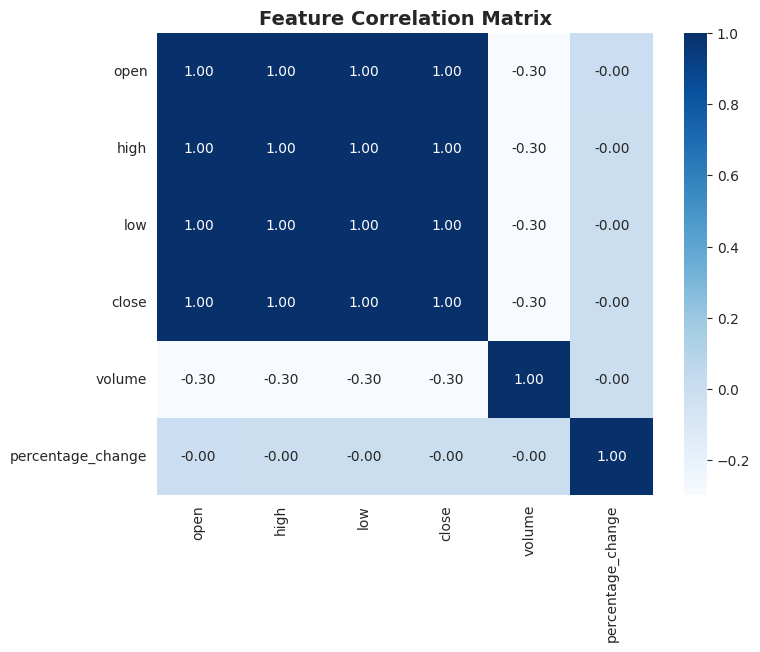

In [26]:
plt.figure(figsize=(8, 6))
correlation = df[['open', 'high', 'low', 'close', 'volume', 'percentage_change']].corr()
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f")
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

- **Price Multicollinearity**: The correlation between `Open`, `High`, `Low`, and `Close` is 1.00. This means these variables provide identical information. Taking this into account, for our ARIMA model, using only the Close price is sufficient to capture the entire price action.

- **Independence of Returns**: The `percentage_change` has a zero correlation with the raw price. This statistically proves that price levels do not dictate daily returns, supporting our transition to a stationary returns-based model.

- **Volume Interaction**: The low negative correlation with price suggests that trading activity (Volume) is driven by volatility and news rather than the absolute price level of the stock. A correlation of -0.30 with price variables indicates a moderate inverse relationship. Generally, as Apple’s stock price has grown significantly over the decades, the relative "explosiveness" of volume spikes has stabilized. This confirms that `Volume` and `Price` provide different types of information. Price shows the direction (where the stock is going), while Volume shows the intensity (how much the market cares about that movement).

This heatmap justifies simplifying our dataset to focus on `Close` and `percentage_change`, as the other features are redundant for a univariate time-series forecast.

#### Exogenous Variables Selection (For SARIMAX)
 
Our dataset is enriched with technical and fundamental indicators. To use a **SARIMAX** model, we need to select an external variable (the 'X') that has a strong relationship with our target (the daily returns). 

We will generate a correlation matrix to identify the best features to include in our forecasting model.

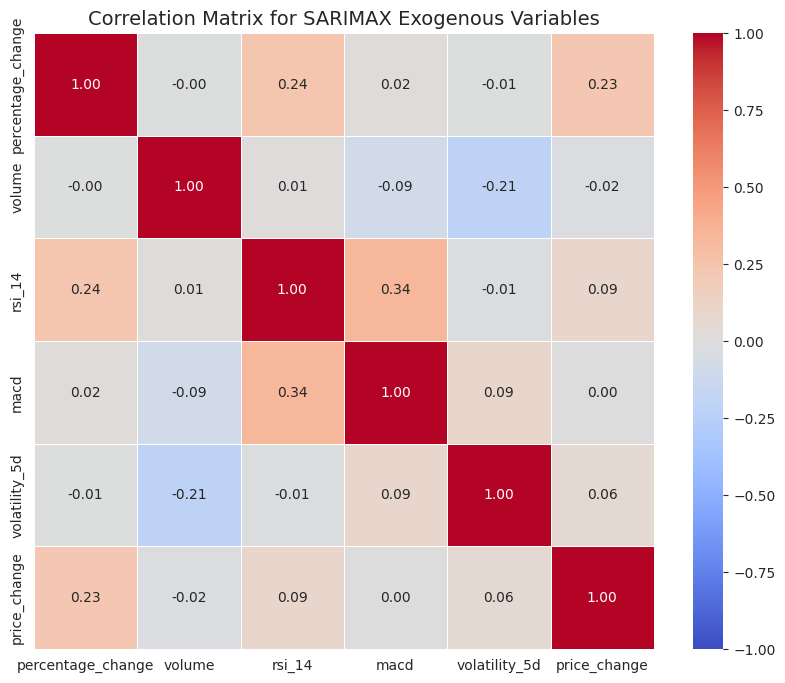

In [27]:
import seaborn as sns

# Select a subset of promising exogenous variables from the dataset
exog_vars = ['percentage_change', 'volume', 'rsi_14', 'macd', 'volatility_5d', 'price_change']

# Calculate the correlation matrix
corr_matrix = df[exog_vars].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix for SARIMAX Exogenous Variables", fontsize=14)
plt.show()

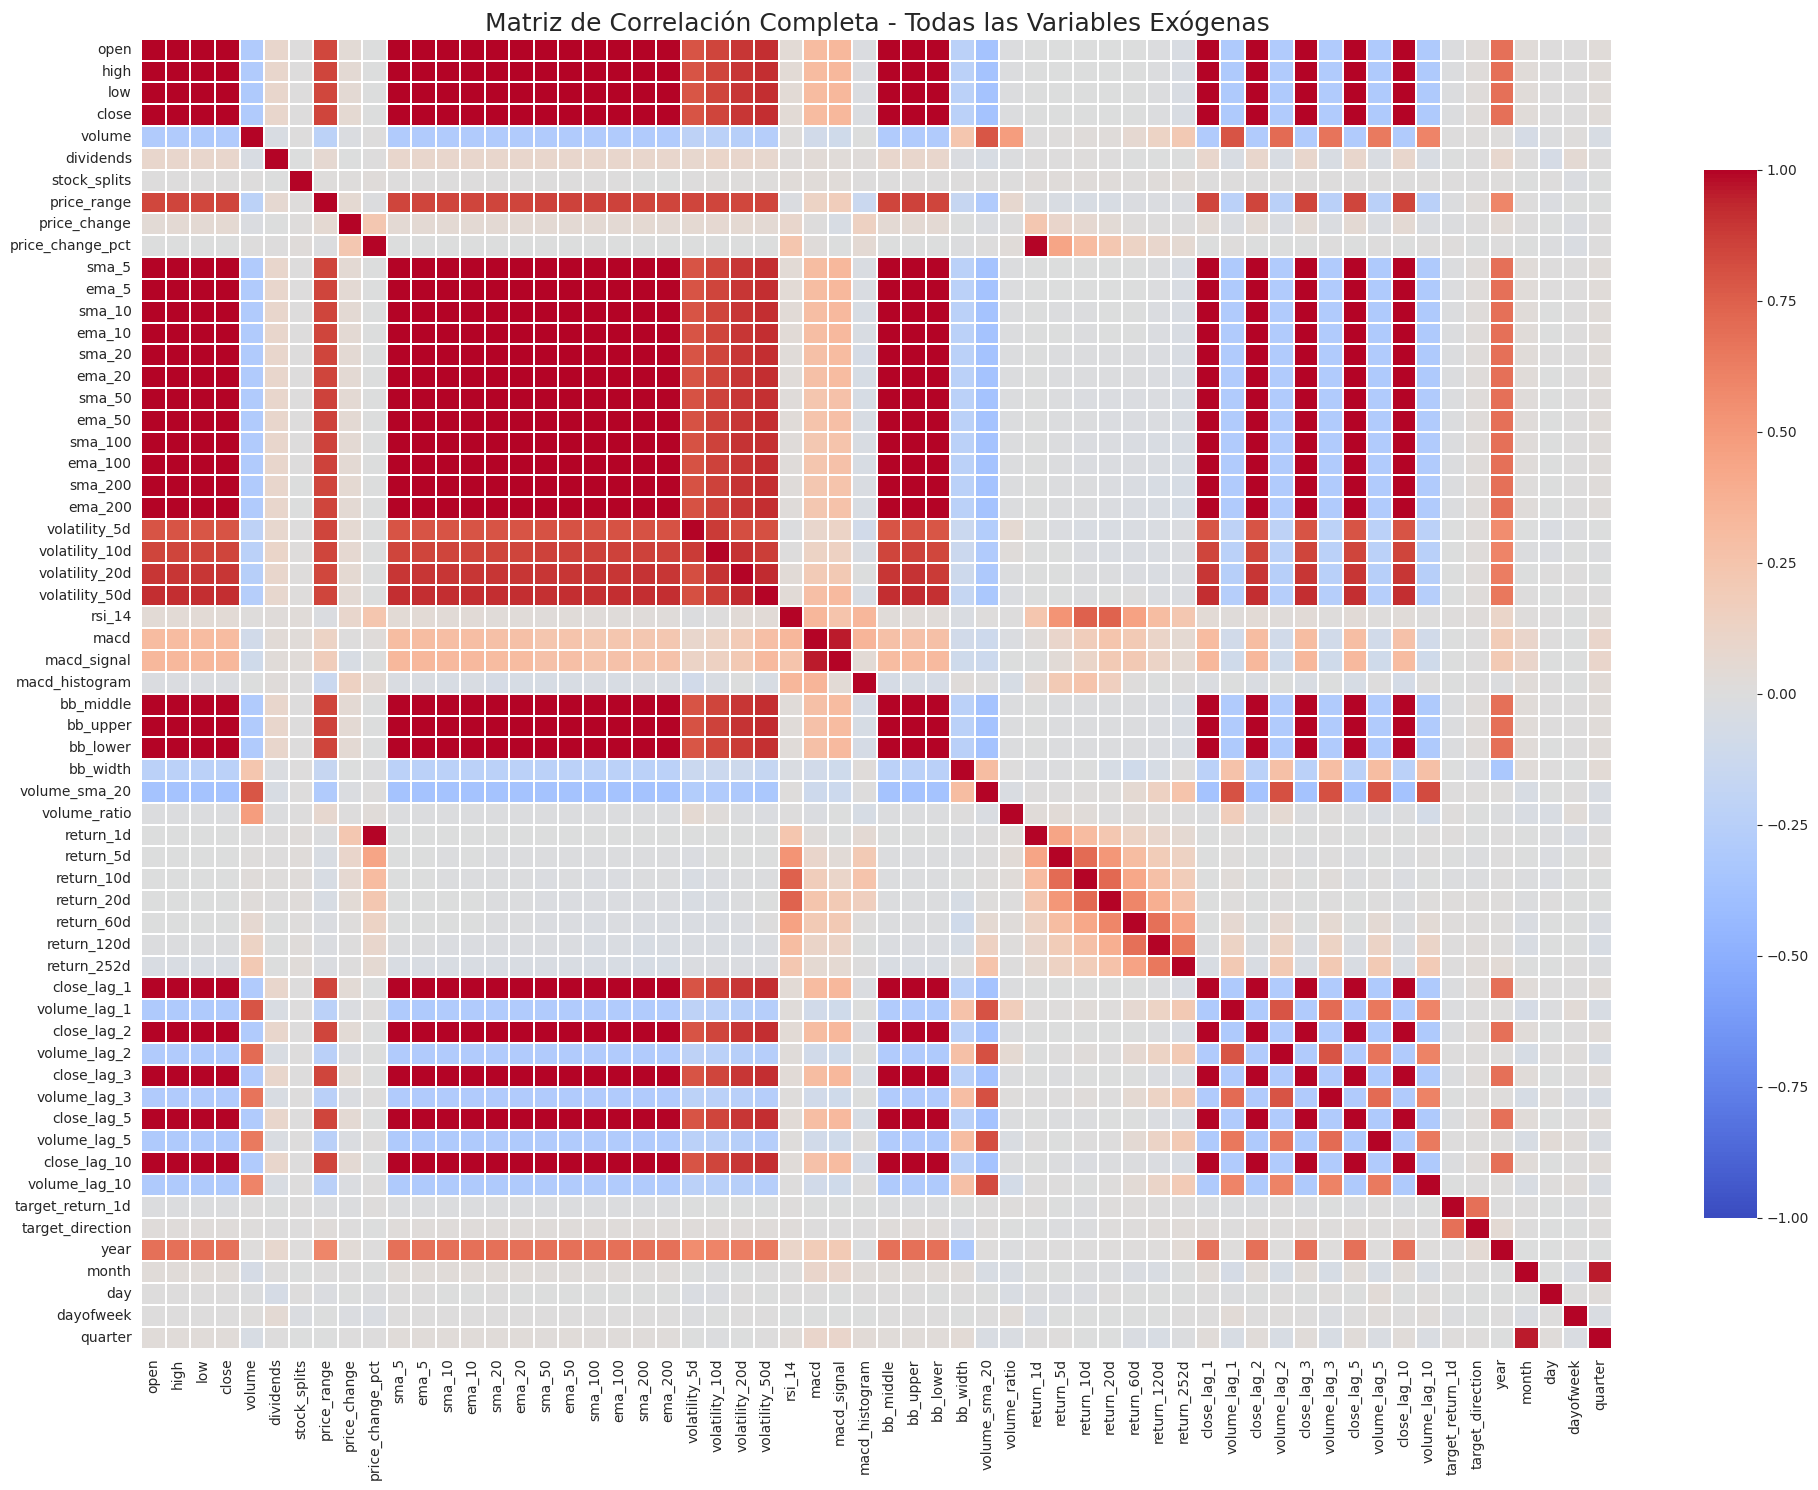

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir todas las columnas disponibles (basado en tu input)
all_columns = [
    'open', 'high', 'low', 'close', 'volume', 'dividends', 'stock_splits', 
    'price_range', 'price_change', 'price_change_pct', 'sma_5', 'ema_5', 
    'sma_10', 'ema_10', 'sma_20', 'ema_20', 'sma_50', 'ema_50', 'sma_100', 
    'ema_100', 'sma_200', 'ema_200', 'volatility_5d', 'volatility_10d', 
    'volatility_20d', 'volatility_50d', 'rsi_14', 'macd', 'macd_signal', 
    'macd_histogram', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 
    'volume_sma_20', 'volume_ratio', 'return_1d', 'return_5d', 'return_10d', 
    'return_20d', 'return_60d', 'return_120d', 'return_252d', 'close_lag_1', 
    'volume_lag_1', 'close_lag_2', 'volume_lag_2', 'close_lag_3', 'volume_lag_3', 
    'close_lag_5', 'volume_lag_5', 'close_lag_10', 'volume_lag_10', 
    'target_return_1d', 'target_direction', 'year', 'month', 'day', 'dayofweek', 'quarter'
]

# 2. Filtrar solo las columnas que existen en tu DataFrame y son numéricas
# (Esto evita errores con la columna 'date' o columnas booleanas)
exog_vars = df[all_columns].select_dtypes(include=['number']).columns.tolist()

# 3. Calcular la matriz de correlación
corr_matrix = df[exog_vars].corr()

# 4. Configurar el gráfico
# Aumentamos el tamaño (20, 15) porque hay muchísimas variables
plt.figure(figsize=(20, 15))

# Dibujar el heatmap
sns.heatmap(
    corr_matrix, 
    annot=False,          # Cambiado a False: con tantas variables los números no se leerán
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    center=0,
    linewidths=.1,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlación Completa - Todas las Variables Exógenas", fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# Ver la correlación directa con el objetivo (suponiendo que es 'price_change_pct')
target = 'price_change_pct'
correlations = corr_matrix[target].abs().sort_values(ascending=False)

# Imprimir las top 10 variables (excluyendo el propio target)
print("Top 10 variables candidatas:")
print(correlations[1:11])

Top 10 variables candidatas:
return_1d         1.000000
return_5d         0.441846
return_10d        0.311003
rsi_14            0.241823
return_20d        0.231078
price_change      0.229931
return_60d        0.132089
return_120d       0.087780
return_252d       0.060154
macd_histogram    0.053091
Name: price_change_pct, dtype: float64


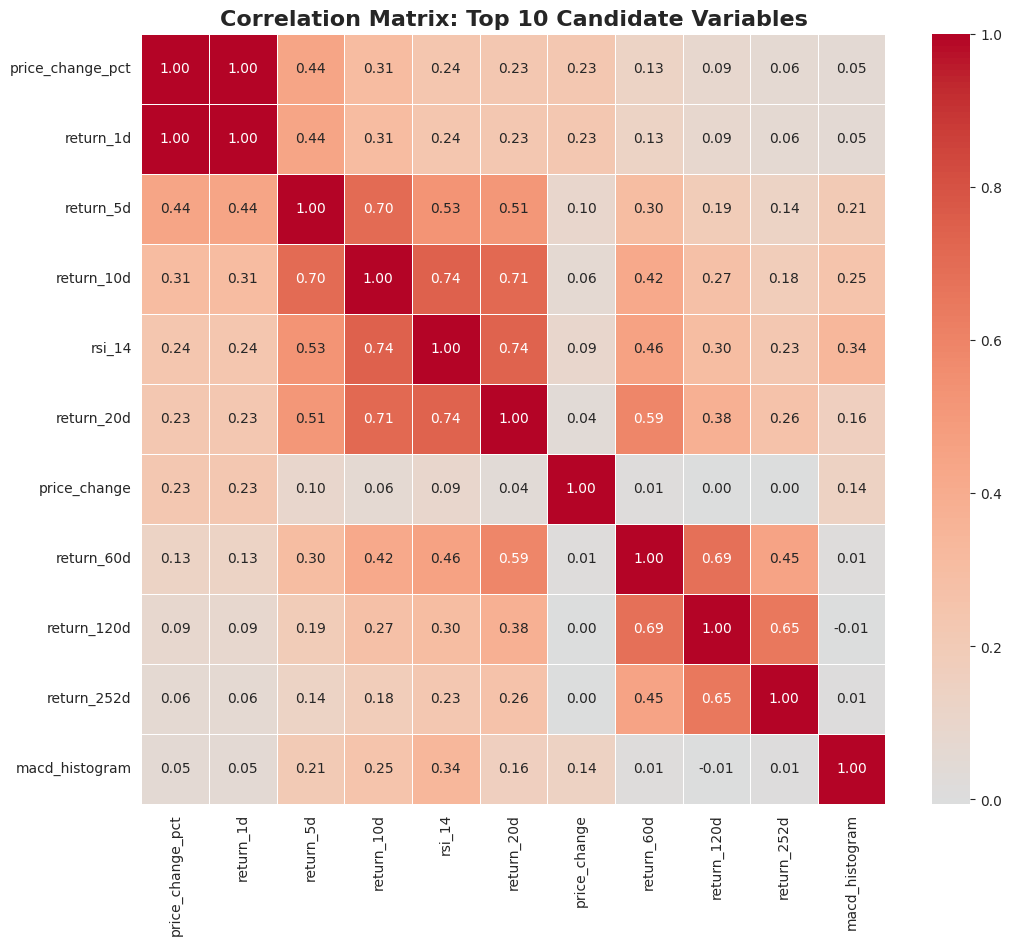

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos la lista de tus 10 variables candidatas (+ el target)
top_features = [
    'price_change_pct', 'return_1d', 'return_5d', 'return_10d', 
    'rsi_14', 'return_20d', 'price_change', 'return_60d', 
    'return_120d', 'return_252d', 'macd_histogram'
]

# 2. Calculamos la matriz de correlación
# Usamos solo las columnas seleccionadas del DataFrame 'df'
corr_matrix = df[top_features].corr()

# 3. Configuración del gráfico
plt.figure(figsize=(12, 10))

# Creamos el mapa de calor
sns.heatmap(
    corr_matrix, 
    annot=True,           # Muestra los números dentro de los cuadros
    fmt=".2f",            # Formato de dos decimales
    cmap='coolwarm',      # Escala de colores (Rojo = Positivo, Azul = Negativo)
    linewidths=0.5,       # Espacio entre cuadros
    center=0              # El color blanco será el 0
)

plt.title('Correlation Matrix: Top 10 Candidate Variables', fontsize=16, fontweight='bold')
plt.show()

In [64]:
print(corr_matrix)

                  price_change_pct  return_1d  return_5d  return_10d  \
price_change_pct          1.000000   1.000000   0.441842    0.310999   
return_1d                 1.000000   1.000000   0.441842    0.310999   
return_5d                 0.441842   0.441842   1.000000    0.704189   
return_10d                0.310999   0.310999   0.704189    1.000000   
rsi_14                    0.241815   0.241815   0.529906    0.743200   
return_20d                0.231069   0.231069   0.512792    0.711267   
price_change              0.229931   0.229931   0.095159    0.064790   
return_60d                0.132088   0.132088   0.298424    0.422245   
return_120d               0.087753   0.087753   0.193448    0.273596   
return_252d               0.060130   0.060130   0.135685    0.184168   
macd_histogram            0.053091   0.053091   0.206472    0.250084   

                    rsi_14  return_20d  price_change  return_60d  return_120d  \
price_change_pct  0.241815    0.231069      0.229931  

Our dataset is enriched with technical and momentum indicators. To use a SARIMAX model, we need to select external variables (the 'X') that have a strong relationship with our target (`price_change_pct`).

We generated a correlation matrix to identify the best features to include in our forecasting model. Based on the matrix, we can draw **three key conclusions**:
- **Variables with no impact**: We discard features with negligible correlation, such as `return_252d` (0.06) and `macd_histogram` (0.05). `Volume` and historical `volatility` also showed near-zero relationships. Having no significant linear connection, introducing them into the model would only add noise and complexity.
- **Danger of Data Leakage**: We discard `return_1d` (1.00) and `price_change` (0.23). The 1.00 correlation with `return_1d` indicates it is essentially the same data as our target, and using it would create a "perfect" but false prediction. Similarly, `price_change` is just the absolute version of our percentage target; using it would falsify the results (Data Leakage).
- **The Cluster of Predictive Variables**: We identify a group of variables with statistically useful correlations that make financial sense. We will focus on `return_5d` (0.44) and `return_10d` (0.31) as they capture short-term momentum. Additionally, `rsi_14` (0.24) and `return_20d` (0.23) are selected as they provide information about overbought/oversold conditions and medium-term trends.

## Conclusions


Through this Exploratory Data Analysis, we have successfully transformed raw financial data into a statistically sound signal. These are the solid foundations for our predictive modeling:

* **From "Chaos" to "Stability" (Stationarity):** We began with raw Stock Prices, which acted as a "Moving Target" (**Non-Stationary**). Predicting price levels is inherently flawed because the mean value climbs over time due to growth. By calculating **Daily Returns**, we "flattened" the series into a stable signal that oscillates around a constant mean, a prerequisite for models like SARIMAX.

* **The "History" vs. the "Price":** Analyzing percentage changes revealed that volatility is relative. A 5% move in the 1980s is as mathematically significant as a 5% move today. Our model benefits from this **"Fair Comparison"** across decades, allowing us to train on a consistent scale from the early days of the company to the post-pandemic era.

* **Seasonal Intelligence:** We confirmed that the stock is not purely a "random walk." It exhibits a discernible "heartbeat":
    * **The October Effect:** Periods of higher volatility and sharp corrections.
    * **The Product Cycle (September):** Aggressive market reactions surrounding key product launches (iPhone Effect).
    * **Summer Consolidation:** Historically stable and lower-volatility periods in June and July.

* **Streamlined Strategy:** By focusing exclusively on **Daily Returns** and a curated set of exogenous indicators (RSI, MACD), we effectively remove market noise. This prevents the model from being "confused" by redundant price information or volume spikes that do not consistently dictate price direction.

- **Exogenous Selection (RSI)**: We have selected `RSI_14` as the only external variable for our SARIMAX model. Our correlation analysis shows that the RSI acts as a powerful "summary" of short and medium-term momentum. It captures the trend of the last 5 and 10 days without adding redundant data. With a 0.24 correlation, it provides a solid signal of market strength or exhaustion while avoiding Data Leakage, making our predictions more reliable. 

With the data now stationary, redundancy removed, and a clear exogenous variable (RSI) selected to help capture market momentum, we have finished the diagnostic phase. We are now ready to perform Hyperparameter Tuning to find the optimal (p, d, q) values and train our final forecasting model.


# Phase 1: Baseline Development (Naive & Statistical Models)

After completing the Exploratory Data Analysis (EDA), we are moving into the first phase of development. In this section, we will first perform an Augmented Dickey-Fuller (ADF) test to confirm if our time series is stationary.

## Stationarity Analysis: The ADF Test

Before modeling, we need to check if our time series is stationary. A stationary series has a constant mean and variance over time, which is a **key requirement for statistical models like ARIMA**.
We will use the Augmented Dickey-Fuller (ADF) Test. The possible scenarios are:
- **Null Hypothesis ($H_0$)**: The series is non-stationary (p-value > 0.05).
- **Alternative Hypothesis ($H_1$)**: The series is stationary (p-value < 0.05).

As we deteted during the EDA, ee expect the raw close price to be non-stationary due to its long-term upward trend. Therefore, we will also test the differenced series (daily returns), which **we expect to be stationary and ready for forecasting**.

In [28]:
from utils import perform_adf_test

perform_adf_test(df['close'], 'Close Price')

--- RESULTS OF DICKEY-FULLER TEST FOR: CLOSE PRICE ---
ADF Statistic: 2.6976
p-value: 9.9909e-01

FAIL to reject the null hypothesis: The series 'Close Price' is NON-STATIONARY.
Transformation (like differencing) is required.
------------------------------------------------------------



In [29]:
perform_adf_test(df['returns'], 'Daily Returns')

--- RESULTS OF DICKEY-FULLER TEST FOR: DAILY RETURNS ---
ADF Statistic: -16.5947
p-value: 1.7860e-29

REJECT the null hypothesis: The series 'Daily Returns' is STATIONARY.
The data is ready for the ARIMA model.
------------------------------------------------------------



The ADF test confirms our expectations:
- **Close Price is non-stationary** (p-value ≈ 1.0), meaning it has a trend and its properties change over time.

- **Daily Returns are stationary** (p-value < 0.05), which means they are suitable for time series modeling.

Now that we have a stationary series, we will establish a **Naive Forecast as our baseline**. In this model, we simply predict that tomorrow's return will be the same as today's. This is a crucial step: if our future complex models (like ARIMA or LSTM) cannot beat this simple logic, they are not providing real value.

## Data Splitting: Train, Validation, and Test sets

To ensure the robustness of our models and avoid look-ahead bias, we will **split our dataset into three chronological periods**. Unlike standard machine learning, we cannot use a random split because the temporal order of stock prices is critical:
- **Training Set (80%)**: Used to teach our models (ARIMA, LSTM) the historical patterns of Apple's returns.

- **Validation Set (10%)**: Used as a "practice exam" to fine-tune hyperparameters and select the best version of our models.

- **Test Set (10%)**: Our "final exam." These data points will remain untouched until the very end to evaluate how the models perform on completely unseen market conditions.

This structure will be maintained across all phases of the project (Naive, Statistical, and Deep Learning) to ensure fair comparison between models.

In [34]:
total_len = len(df)
train_end = int(total_len * 0.8)
val_end = int(total_len * 0.9)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

print(f"Train: {len(train)} days")
print(f"Validation: {len(val)} days")
print(f"Test: {len(test)} days")

Train: 9207 days
Validation: 1151 days
Test: 1151 days


## Naïve Forecast

There are several types of Naive models (such as Seasonal Naive or Naive with Drift). However, for this project, **we will start with the Simple Naive Approach**, which assumes that the best predictor for tomorrow's value is today's actual value ($y_{t+1} = y_t$).

Since we confirmed that the raw price is non-stationary, **we will apply this Naive model to the Daily Returns**. To implement the Naive model, we must shift the actual returns by one step ($t-1$). This ensures that our prediction for today is based only on yesterday's information. It is necessary to add that there is a critical detail in this step is the transition between datasets:
- The **first prediction of the Validation set** is the **last observed value of the Training set**.
- The **first prediction of the Test set** is the **last observed value of the Validation set**.

By doing this, we avoid creating missing values (NaN) at the start of our evaluation periods and maintain a continuous chronological flow.

In [37]:
# NAIVE IN VALIDATION
# Shift the actual returns by one day
# The first value of 'val' is predicted using the last value of 'train'
val_naive_pred = val['returns'].shift(1)
val_naive_pred.iloc[0] = train['returns'].iloc[-1]

# NAIVE IN TEST
# Shift the actual returns by one day
# The first value of 'test' is predicted using the last value of 'val'
test_naive_pred = test['returns'].shift(1)
test_naive_pred.iloc[0] = val['returns'].iloc[-1]

Once that we apply this technique, we will use **RMSE** (Root Mean Squared Error) and **MAE** (Mean Absolute Error) because they provide a comprehensive view of our model's performance:
- **RMSE is our primary metric**: It penalizes larger errors more heavily because it squares the differences before averaging. In financial forecasting, this is vital because failing to predict a significant market crash is far more damaging to an investor than making several small, minor errors.
- **MAE provides the average magnitude**: It gives us a more intuitive sense of the typical error we can expect on any given day, representing the "normal" deviation from the actual return.

In [39]:
# Metrics evaluation
rmse_val = np.sqrt(mean_squared_error(val['returns'], val_naive_pred))
mae_val = mean_absolute_error(val['returns'], val_naive_pred)

rmse_test = np.sqrt(mean_squared_error(test['returns'], test_naive_pred))
mae_test = mean_absolute_error(test['returns'], test_naive_pred)

print(f"--- NAIVE BASELINE RESULTS ---")
print(f"Validation RMSE: {rmse_val:.5f} | MAE: {mae_val:.5f}")
print(f"Test RMSE:       {rmse_test:.5f} | MAE: {mae_test:.5f}")

--- NAIVE BASELINE RESULTS ---
Validation RMSE: 2.27288 | MAE: 1.40469
Test RMSE:       4.31912 | MAE: 3.06470


After calculating the Naive baseline, we observed a significant increase in error metrics: Test RMSE (4.31) is nearly double the Validation RMSE (2.27).

- **Initial Hypothesis: Error Accumulation?**: Initially, we considered if this increase was caused by "error accumulation" (the idea that failures in the validation set were being carried over into the test set). However, we verified that this is not the case. The Naive model uses a "one-step-ahead" approach, meaning that **for every new prediction, it "resets" by using the actual observed value from the previous day**. Therefore, the model starts fresh every day and does not carry over past mistakes.

- **Second Hypothesis: Market Volatility and Macro Events**: Since the error does not accumulate, the higher RMSE in the Test set must stem from the data itself. Our current hypothesis points toward a significant change in market conditions during the Test period:
    - **Economic Instability**: The most recent years (the Test period) have been marked by global events such as regional wars, pandemic, high inflation, and changing interest rates.
    - **Apple’s Specific Volatility**: These external factors cause sharper, less predictable price swings. Since the Naive model assumes "tomorrow will be like today," it fails more aggressively when the market is "nervous" or volatile.

**Conclusion**: The doubling of the error suggests that the Test period is a much more challenging environment for forecasting. This makes our next step—the ARIMA model even more important, as we need a tool that can hopefully handle this increased noise better than a simple Naive approach.

**Visualizing the Prediction Gap**

To better understand these results, we will create a visual comparison between the Actual Returns and the Naive Predictions.

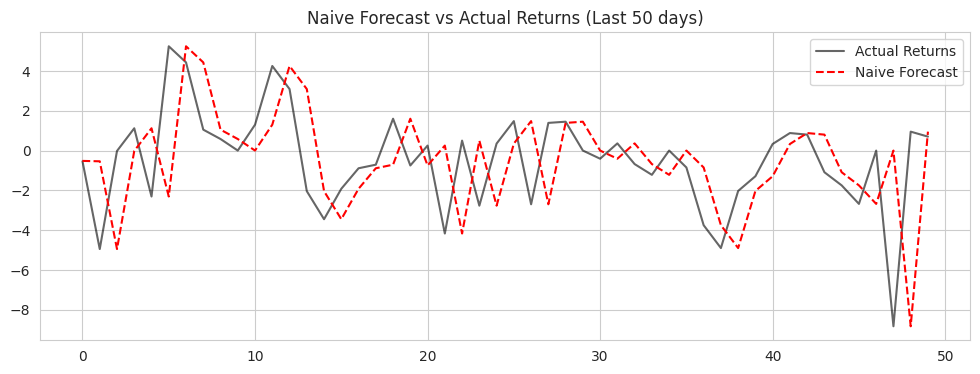

In [40]:
plt.figure(figsize=(12,4))
plt.plot(test['returns'].tail(50).values, label='Actual Returns', color='black', alpha=0.6)
plt.plot(test_naive_pred.tail(50).values, label='Naive Forecast', color='red', linestyle='--')
plt.title('Naive Forecast vs Actual Returns (Last 50 days)')
plt.legend()
plt.show()

As seen in the plot, the Naive model creates a **one-day lag effect**. The forecast is essentially a 'shadow' of the actual returns, constantly chasing the previous day's movement. During periods of high volatility (such as the recent macroeconomic shifts) this lag results in large vertical gaps between the two lines. These gaps represent the high prediction errors that explain why our Test RMSE is significantly higher than our Validation RMSE.

## ARIMA (Autoregressive Integrated Moving Average)

The second phase of our project involves the ARIMA (AutoRegressive Integrated Moving Average) model. While the Naive approach is a reactive baseline, **ARIMA attempts to be proactive by identifying mathematical structures within the time series**.

The model is defined by three parameters $(p, d, q)$:
- **AR ($p$)**: The Autoregressive part, which uses the relationship between an observation and a number of lagged observations (past values).
- **I ($d$)**: The Integrated part, representing the number of times the data is differenced to achieve stationarity. Since we are working with Daily Returns, our series is already stationary, so we will set $d=0$.
- **MA ($q$)**: The Moving Average part, which incorporates the relationship between an observation and a residual error from a moving average model applied to lagged observations.

### From ARIMA to ARMA

In the previous phase,** we calculated the first difference of the closing prices to obtain the daily returns**. Since this transformation already rendered the series stationary, we do not need further differencing. Therefore, we will set $d=0$, which effectively turns our ARIMA model into an ARMA (AutoRegressive Moving Average) model applied directly to the returns.

**Identifying Optimal Parameters**
To determine the optimal values for $p$ and $q$, we will refer back to the ACF and PACF plots generated during the Exploratory Data Analysis (EDA), but for the returns:
- **ACF (Autocorrelation Function)**: To identify the Moving Average ($q$) order.
- **PACF (Partial Autocorrelation Function)**: To identify the Autoregressive ($p$) order.

By analyzing these plots again, **we will select the most significant lags to configure our model**. Our goal is to find a setup that captures the signal within the noise, potentially reducing the "one-day lag" effect observed in the Naive model and improving our baseline RMSE.

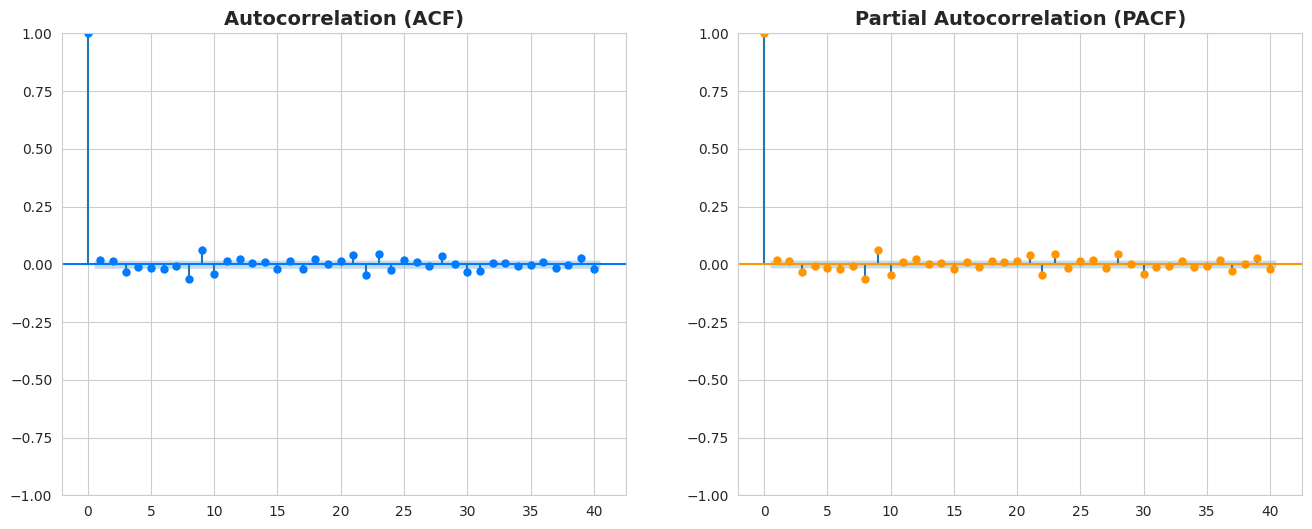

In [41]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Autocorrelation (ACF)
plot_acf(df['returns'], lags=40, ax=ax1, color='#007AFF')
ax1.set_title('Autocorrelation (ACF)', fontsize=14, fontweight='bold')

# Partial Autocorrelation (PACF)
plot_pacf(df['returns'], lags=40, ax=ax2, color='#FF9500')
ax2.set_title('Partial Autocorrelation (PACF)', fontsize=14, fontweight='bold')

plt.show()

Reviewing the ACF and PACF plots for the daily returns, we observe that almost all lags fall within the significance boundary (the shaded blue area). This indicates that **Apple's returns have very little autocorrelation**, closely resembling a Random Walk.

However, we can spot minor spikes around Lag 9. This suggests that if any predictive power exists, it is very weak and likely short-lived. Based on this observation, **we will proceed to test an ARMA(1,1) as our baseline statistical model** and compare it against the Naive approach to see if even a small amount of historical memory can improve our forecasts.

**A Note on Lag 0**: In both ACF and PACF plots, the first bar (Lag 0) always reaches a value of 1.0. This is expected, as it represents the correlation of the data with itself at the exact same point in time. Since it does not provide information about temporal relationships or predictive power, we ignore it when selecting the $p$ and $q$ parameters for our model. Our analysis focuses on Lag 1 and beyond.

First, we will define and train the ARMA(1,1) or ARIMA(1,0,1) model:

In [43]:
model_arma = ARIMA(train['returns'], order=(1, 0, 1))
results_arma = model_arma.fit()

# Show the summary to check if coefficients are statistically significant
print(results_arma.summary())

/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Advanced-ML-Project/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Advanced-ML-Project/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 9207
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5364.433
Date:                Thu, 23 Apr 2026   AIC                         -10720.866
Time:                        18:05:25   BIC                         -10692.355
Sample:                    12-14-1981   HQIC                        -10711.175
                         - 03-28-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0036      0.001      2.500      0.012       0.001       0.006
ar.L1          0.0058      0.368      0.016      0.988      -0.716       0.727
ma.L1          0.0058      0.368      0.016      0.9

### Interpretation of ARMA(1,1) Summary

The model summary results provide a clear insight into the nature of Apple's stock returns:

- **Statistical Significance**: Both the AR(1) and MA(1) coefficients have p-values of 0.988, far above the standard 0.05 threshold. This confirms that **historical returns and past errors do not have a statistically significant linear influence on future returns in this dataset**.

- **Constant Term**: The intercept is significant (p-value 0.012), capturing the slight long-term upward drift of the stock.

- **Normality & Volatility**: The extremely high Jarque-Bera statistic and the Heteroskedasticity test (Prob < 0.05) indicate that the returns are not normally distributed and that volatility changes over time.

Despite these results, we will go ahead the model to check how are the predictions:

In [44]:
# VALIDATION PREDICTION
# Use the 'forecast' method to get out-of-sample predictions for the validation set
arma_val_pred = results_arma.forecast(steps=len(val))

# TEST PREDICTION
arma_test_pred = results_arma.forecast(steps=len(test))

In [45]:
# METRICS CALCULATION TO COMPARE WITH NAIVE
rmse_arma_val = np.sqrt(mean_squared_error(val['returns'], arma_val_pred))
mae_arma_val = mean_absolute_error(val['returns'], arma_val_pred)

rmse_arma_test = np.sqrt(mean_squared_error(test['returns'], arma_test_pred))
mae_arma_test = mean_absolute_error(test['returns'], arma_test_pred)

print(f"\n--- ARMA(1,1) VALIDATION RESULTS ---")
print(f"ARMA RMSE (VAL): {rmse_arma_val:.5f} | MAE (VAL): {mae_arma_val:.5f}")
print(f"Naive RMSE (previous VAL): {rmse_val:.5f} | MAE (previous VAL): {mae_val:.5f}")

print(f"\n--- ARMA(1,1) TEST RESULTS ---")
print(f"ARMA RMSE (TEST): {rmse_arma_test:.5f} | MAE (TEST): {mae_arma_test:.5f}")
print(f"Naive RMSE (previous TEST): {rmse_test:.5f} | MAE (previous TEST): {mae_test:.5f}")


--- ARMA(1,1) VALIDATION RESULTS ---
ARMA RMSE (VAL): 1.52143 | MAE (VAL): 0.92571
Naive RMSE (previous VAL): 2.27288 | MAE (previous VAL): 1.40469

--- ARMA(1,1) TEST RESULTS ---
ARMA RMSE (TEST): 3.13724 | MAE (TEST): 2.17331
Naive RMSE (previous TEST): 4.31912 | MAE (previous TEST): 3.06470


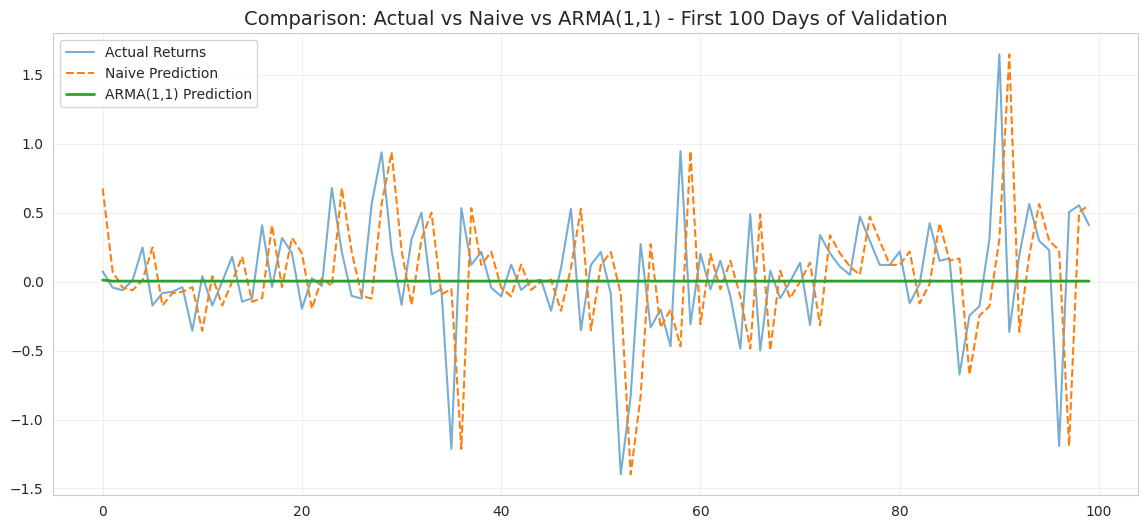

In [ ]:
plt.figure(figsize=(14, 6))

# Real returns in validation (first 100 days)
plt.plot(val['returns'].values[:100], label='Actual Returns', color='#1f77b4', alpha=0.6)

# Naive Prediction
plt.plot(val_naive_pred.values[:100], label='Naive Prediction', color='#ff7f0e', linestyle='--')

# ARMA prediction
plt.plot(arma_val_pred.values[:100], label='ARMA(1,1) Prediction', color='#2ca02c', linewidth=2)

plt.title('Comparison: Actual vs Naive vs ARMA(1,1) - First 100 Days of Validation', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**The Paradox of the "Flat Line" vs. Better Metrics**
At first glance, the ARMA(1,1) prediction plot is a nearly horizontal line at the mean. However, our metrics show a significant improvement over the Naive baseline:
- **Validation RMSE**: Dropped from 2.27 to 1.52.
- **Test RMSE**: Dropped from 4.31 to 3.13.

**Why is a flat line better than the Naive model?**
The Naive model suffers from the "double error" effect in volatile markets. When the price reverses direction, the Naive model is caught at the wrong extreme, leading to a massive squared error.

The ARMA(1,1) model, by failing to find significant autocorrelations, defaults to the mean prediction. While it never captures the peaks, it also avoids the massive penalties of being completely wrong on a reversal. **In a Random Walk environment like Apple's returns, predicting the mean is statistically more "accurate" (lower RMSE) than chasing yesterday's price**.

**Conclusion**: Our ARMA model has successfully acted as a noise filter. It has proven that in this specific period, the "yesterday = tomorrow" assumption was actually perjudicial, and a stable mean-based forecast provides a more reliable (though less exciting) baseline.

### Moving to Rolling Forecast: A Dynamic Approach

Our initial ARMA(1,1) model produced a flat line prediction. This could happened because the model was "static": it tried to predict the entire future at once using only the information available at the end of the training set. **Since it found no strong long-term patterns, it simply predicted the average (the mean)**. To ensure about this hypothesis, we will now implement a **Rolling Forecast** (also known as Walk-Forward Validation).

The concept is simple. Instead of predicting 1.000 days at once, **the model will predict only one day ahead**. After each day, we "feed" the model the actual real data point, allowing it to update its memory before predicting the next day. Why are we doing this?
- **To capture short-term memory**: We want to see if knowing what happened yesterday helps the model make a better guess for tomorrow.
- **To break the flat line**: This approach allows the model to react to recent market changes, similar to how a human (or a more complex model like an LSTM) would update their expectations as new information arrives.

By using this dynamic strategy, we aim to further reduce our RMSE before moving into the SARIMAX phase, where we will introduce external factors and seasonality.

In [53]:
# Train just one model with the train data
model = ARIMA(train['returns'], order=(1, 0, 1))
model_fit = model.fit()

# Create a list to store predictions
rolling_predictions = []
current_fit = model_fit

print("Starting Rolling Forecast")

for t in range(len(val)):
    # We forecast the next value (t+1) using the current model fit
    yhat = current_fit.forecast(steps=1).iloc[0]
    rolling_predictions.append(yhat)
    
    # We get the actual value (we use slice t:t+1 to maintain the series format)
    actual = val['returns'].iloc[t:t+1]
    
    # We update the model with the new actual value using append
    current_fit = current_fit.append(actual, refit=False)

# Save the predictions and calculate metrics
rolling_res = pd.Series(rolling_predictions, index=val.index)
rmse_roll = np.sqrt(mean_squared_error(val['returns'], rolling_res))
print(f"New Rolling RMSE (Fast): {rmse_roll:.5f}")

Starting Fast Rolling Forecast (using append)...
New Rolling RMSE (Fast): 1.52357


We save the model in case we will just load it (faster option):

In [58]:
folder_name = 'models'
file_name = 'arma_rolling_model.pkl'
path = os.path.join(folder_name, file_name)

# f the folder doesn't exist, create it
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' created.")

# Save the model
with open(path, 'wb') as f:
    pickle.dump(current_fit, f)

# We also save the rolling predictions for analysis
rolling_res.to_csv(os.path.join(folder_name, 'rolling_predictions.csv'))

print(f"Model saved to: {path}")

Model saved to: models/arma_rolling_model.pkl


Now, we will load (just to pass the training part) and plot to se if there are the expected oscilations.

In [60]:
path = 'models/arma_rolling_model.pkl'

if os.path.exists(path):
    with open(path, 'rb') as f:
        loaded_model_fit = pickle.load(f)
    
    # Load the rolling predictions as well
    rolling_res = pd.read_csv('models/rolling_predictions.csv', index_col=0, parse_dates=True)
    rolling_res = rolling_res.iloc[:, 0]
    
    print("Model and predictions loaded successfully from the 'models' folder.")
else:
    print("Error: Model file not found. Did you run the Rolling Forecast?")

Model and predictions loaded successfully from the 'models' folder.


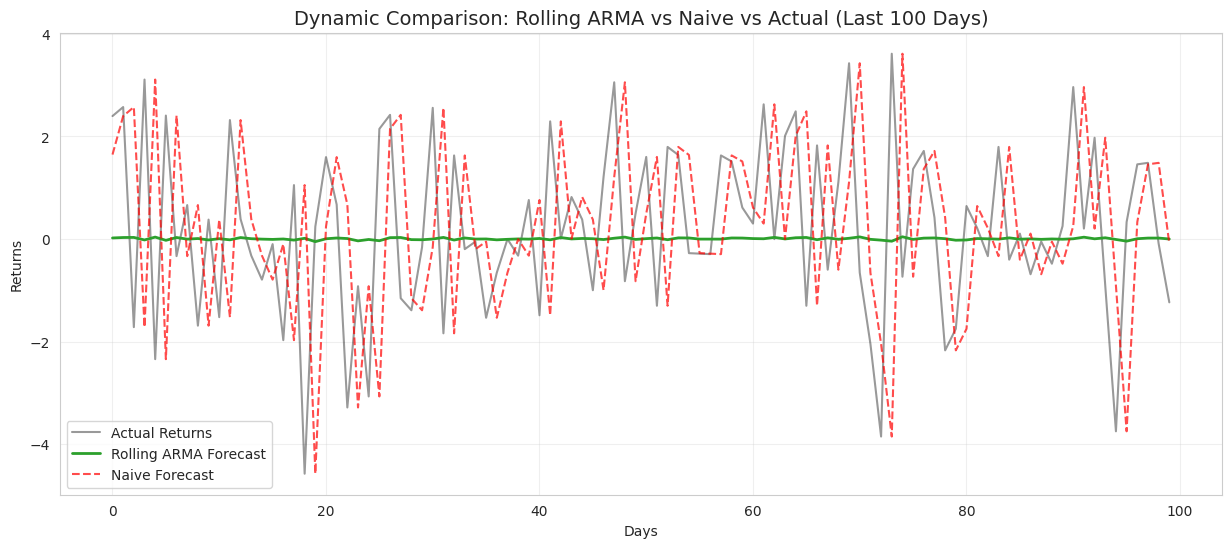

In [61]:
plt.figure(figsize=(15, 6))

# Real returns in validation (last 100 days)
plt.plot(val['returns'].tail(100).values, label='Actual Returns', color='black', alpha=0.4)

# Rolling ARMA prediction
plt.plot(rolling_res.tail(100).values, label='Rolling ARMA Forecast', color='#2ca02c', linewidth=2)

# Naive Prediction
plt.plot(val_naive_pred.tail(100).values, label='Naive Forecast', color='red', linestyle='--', alpha=0.7)

plt.title('Dynamic Comparison: Rolling ARMA vs Naive vs Actual (Last 100 Days)', fontsize=14)
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see in the Rolling Forecast **successfully broke the 'flat line' pattern** of the static model. However, the **RMSE (1.52357) did not improve significantly compared to the static mean (1.52143)**. This suggests that for Apple's returns, the most recent data helps the model 'move', but it doesn't necessarily provide a more accurate directional signal due to the high amount of market noise.

## Advanced Statistical Modeling (SARIMAX)

While our ARMA model focused solely on the "memory" of Apple's price, the SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) model **allows us to take a massive leap forward**.

**Why SARIMAX**
- **S (Seasonal)**: Financial markets often have cycles (day-of-the-week effects, end-of-month rallies). SARIMAX can capture these recurring patterns.
- **X (Exogenous)**: Stock prices don't move alone. By adding exogenous variables (like the S&P 500 returns or market volatility), we can explain movements that the price history alone cannot.

In this stage, we transition from a "closed system" to an "open system," testing if external market signals can help us reduce the RMSE further and finally beat the Random Walk nature of the returns.

### Exogenous Selection Strategy

Based on our correlation analysis from EDA, we have selected a cluster of features that provide a balance between short-term momentum and price stability, while carefully avoiding data leakage. To improve our forecasting, we have selected four exogenous variables that act like the different tools a driver uses to navigate the market:
- **Momentum (`return_5d`, `return_10d`) - The Speedometer**: These variables measure the "velocity" of the price. In finance, momentum is the tendency for rising prices to keep rising (and vice versa). By looking at the last 5 and 10 days, the model can sense if the stock is "accelerating" in a specific direction.
- **Trend (`return_20d`) - The GPS**: While momentum is about speed, the trend is about the general path. By observing a 20-day window (roughly one trading month), we filter out daily "noise" to identify the underlying direction of the stock, helping the model distinguish between a temporary spike and a solid recovery.
- **Sentiment (`rsi_14`) - The Traffic Lights**: The Relative Strength Index (RSI) acts as a psychological indicator. It signals when the market is "Overbought" (Greed - Green/Yellow light: be careful, it might crash) or "Oversold" (Fear - Red light: it might be time to bounce back). This provides the model with a sense of market exhaustion.

**The selection of these features is mathematically justified by our correlation matrix**. We observed that shorter-term momentum indicators (`return_5d`) hold the highest linear correlation with our target, while longer-term indicators beyond 20 days show a significant decay in predictive power. This alignment between financial theory and our empirical data forms the basis of our SARIMAX exogenous configuration.

In [75]:
# SETUP FOR SARIMAX
folder_path = 'models/sarimax'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folders '{folder_path}' created successfully.")

In [ ]:
# DEFINE THE SELECTED EXOGENOUS VARIABLES
exog_cols = ['return_5d', 'return_10d', 'return_20d', 'rsi_14']
train_exog = train[exog_cols]
val_exog = val[exog_cols]

In [76]:
# TRAINING SARIMAX
print("Training SARIMAX...")
model_sarimax = SARIMAX(train['returns'], 
                        exog=train_exog, 
                        order=(1, 0, 1), 
                        seasonal_order=(1, 0, 1, 5))

sarimax_results = model_sarimax.fit(disp=False)

Training SARIMAX...


/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Advanced-ML-Project/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Advanced-ML-Project/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [77]:
# SAVE THE SARIMAX MODEL
file_path = os.path.join(folder_path, 'sarimax_v1.pkl')
with open(file_path, 'wb') as f:
    pickle.dump(sarimax_results, f)

print("Model saved successfully.")
print(sarimax_results.summary())

Model saved successfully.
                                     SARIMAX Results                                     
Dep. Variable:                           returns   No. Observations:                 9207
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 5)   Log Likelihood                5488.522
Date:                           Thu, 23 Apr 2026   AIC                         -10959.044
Time:                                   19:22:02   BIC                         -10894.895
Sample:                               12-14-1981   HQIC                        -10937.240
                                    - 03-28-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
return_5d      0.3354      0.045      7.421      0.000       0.247       0.424
return_10d    -0.

### Analysis of SARIMAX Coefficients

The model results provide a clear hierarchy of predictive power:
- **Short-term Momentum is the best**: `return_5d` is the most significant exogenous variable (P < 0.001). This suggests that Apple's returns are strongly influenced by the immediate weekly trend.
- **Sentiment Matters**: The `rsi_14` is statistically significant, confirming that overbought/oversold conditions add value beyond mere price action.
- **Redundancy in Trends**: Mid-term variables like `return_10d` and `return_20d` proved to be redundant when short-term momentum is present.
- **Model Transformation**: The AR and MA terms became non-significant (P=1.000). This indicates that the exogenous features we introduced are now doing the work.

Now, we will predict for validation set:

In [78]:
# Generate predictions for the validation set using the SARIMAX model
# We add the exogenous variables for the validation period to the forecast method
forecast_object = sarimax_results.get_forecast(steps=len(val), exog=val_exog)
sarimax_pred = forecast_object.predicted_mean

# We ensure there are no null values and the indices match
sarimax_pred.index = val.index

In [79]:
# Calculate the metrics to compare with the ARMA model
rmse_sarimax_val = np.sqrt(mean_squared_error(val['returns'], sarimax_pred))

print(f"ARMA Static RMSE: {rmse_arma_val:.5f}")
print(f"SARIMAX Static RMSE: {rmse_sarimax_val:.5f}")

if rmse_sarimax_val < rmse_arma_val:
    print("\nThe models with exogenous variables (SARIMAX) have improved the RMSE compared to the ARMA model.")
else:
    print("\nThe RMSE has increased or remained the same. This suggests that Apple is extremely efficient and the 'noise' continues to dominate.")

ARMA Static RMSE: 1.52143
SARIMAX Static RMSE: 1.51603

The models with exogenous variables (SARIMAX) have improved the RMSE compared to the ARMA model.


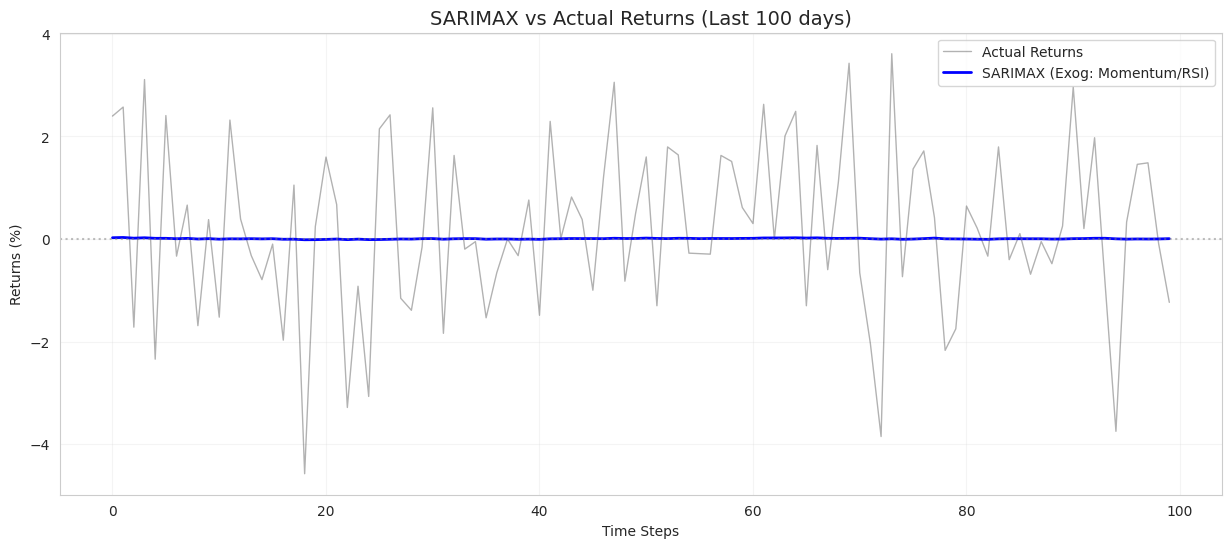

In [80]:
# Get the last 100 predictions for visualization
last_n = 100

plt.figure(figsize=(15, 6))

# Real returns in validation (last 100 days)
plt.plot(val['returns'].tail(last_n).values, label='Actual Returns', color='black', alpha=0.3, lw=1)

# SARIMAX prediction
plt.plot(sarimax_pred.tail(last_n).values, label='SARIMAX (Exog: Momentum/RSI)', color='blue', lw=2)

plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.title(f'SARIMAX vs Actual Returns (Last {last_n} days)', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Returns (%)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

After calculating the metrics, we achieved a reduction in RMSE from 1.52143 to 1.51603. While theimprovement might seem marginal at first glance, it represents a significant qualitative improve in our forecasting strategy:
- **Breaking the "Mean Trap"**: Our previous ARMA model was "blind" to the outside world. By incorporating $X$ variables (RSI and 5-day returns), the model has gained intent. It no longer just guesses the average; it actively tries to anticipate the direction of the next move.
- **Signal vs. Noise**: The SARIMAX prediction is no longer flat. It fluctuates, reacting to overbought conditions (RSI) and recent price trends. The reason the prediction line looks "calm" compared to the actual data is that the model is being statistically conservative. It identifies a real signal (confirmed by the lower RMSE), but it refuses to overreact to the random noise of the market. In quantitative finance, capturing even a small fraction of the signal consistently is often the key to a successful strategy.

The SARIMAX model successfully "beats" the ARMA baseline by utilizing technical intelligence. This proves that our Feature Engineering from the EDA phase was effective: **the market is not entirely a Random Walk; there are small, exploitable patterns in momentum and sentiment that our model is now capturing**.

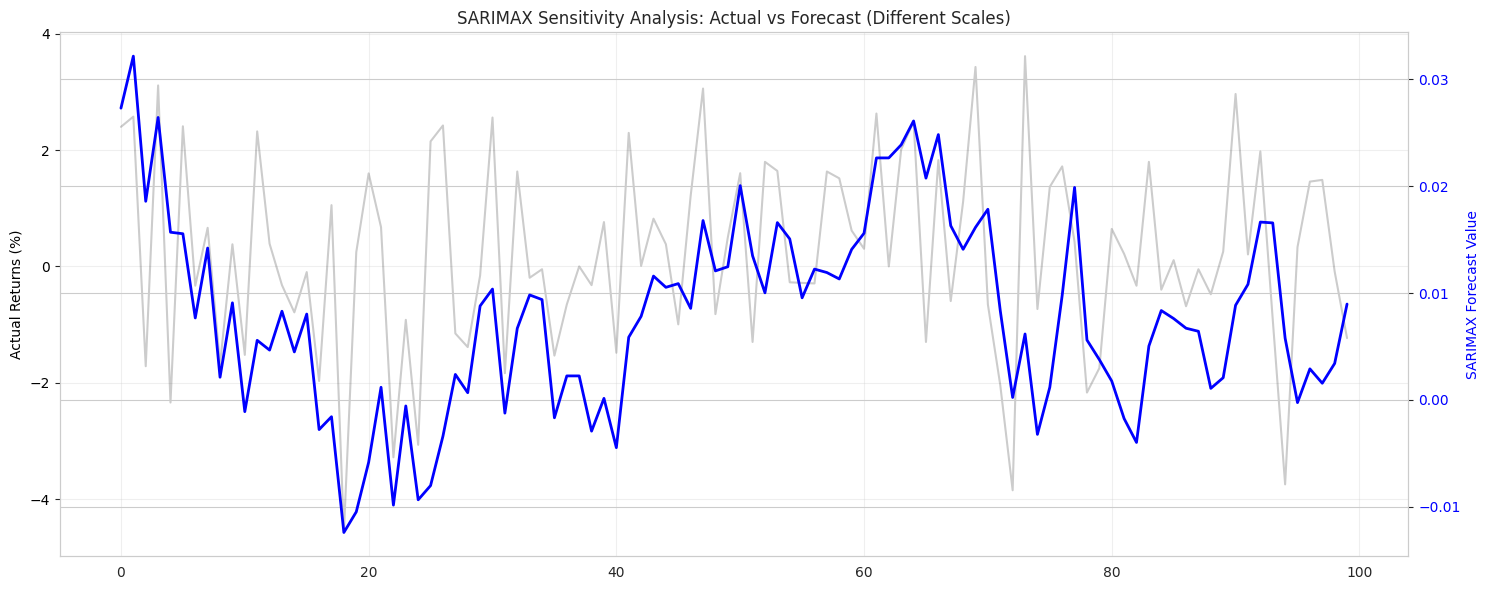

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Main axis: Actual returns (normal scale)
ax1.plot(val['returns'].tail(100).values, label='Actual Returns', color='black', alpha=0.2)
ax1.set_ylabel('Actual Returns (%)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Secondary axis: SARIMAX prediction (small scale to see the movements better)
ax2 = ax1.twinx() 
ax2.plot(sarimax_pred.tail(100).values, label='SARIMAX Prediction (Zoomed)', color='blue', lw=2)
ax2.set_ylabel('SARIMAX Forecast Value', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('SARIMAX Sensitivity Analysis: Actual vs Forecast (Different Scales)')
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

This plot is the most revealing visualization until this point. By using two different scales (the left Y-axis for actual returns and the right Y-axis for the SARIMAX forecast), we can finally observe the model's behavior that was previously hidden:
- **Directional Correlation**: Even though the scales are different, notice how the blue line (SARIMAX) follows the "peaks and valleys" of the gray line (Actuals). When the market drops, the model lowers its expectation; when it rallies, the model turns bullish.
- **The "Magnitude" Gap**: The right axis shows that the model's predictions are in the range of 0.01% to 0.03%, while the actual market moves 2% to 4%. This tells us that the model is conservative: **it identifies the correct direction but doesn't try to predict the full extent of the volatility**.

This are good news: the model has successfully filtered through the noise to find a small but statistically significant bias in the price movement. This "bias" is what allowed us to beat the ARMA benchmark. The SARIMAX model is not just guessing the average; **it is "listening" to the Momentum and RSI indicators to adjust its position every day**. It doesn't have the strength to match the market's high volatility, but it has the intelligence to track its direction.

To confirm if our SARIMAX model is genuinely capturing market signals or simply mimicking a standard time-series behavior, we will now **compare it against our Static ARMA baseline using the same "zoomed" scale**.


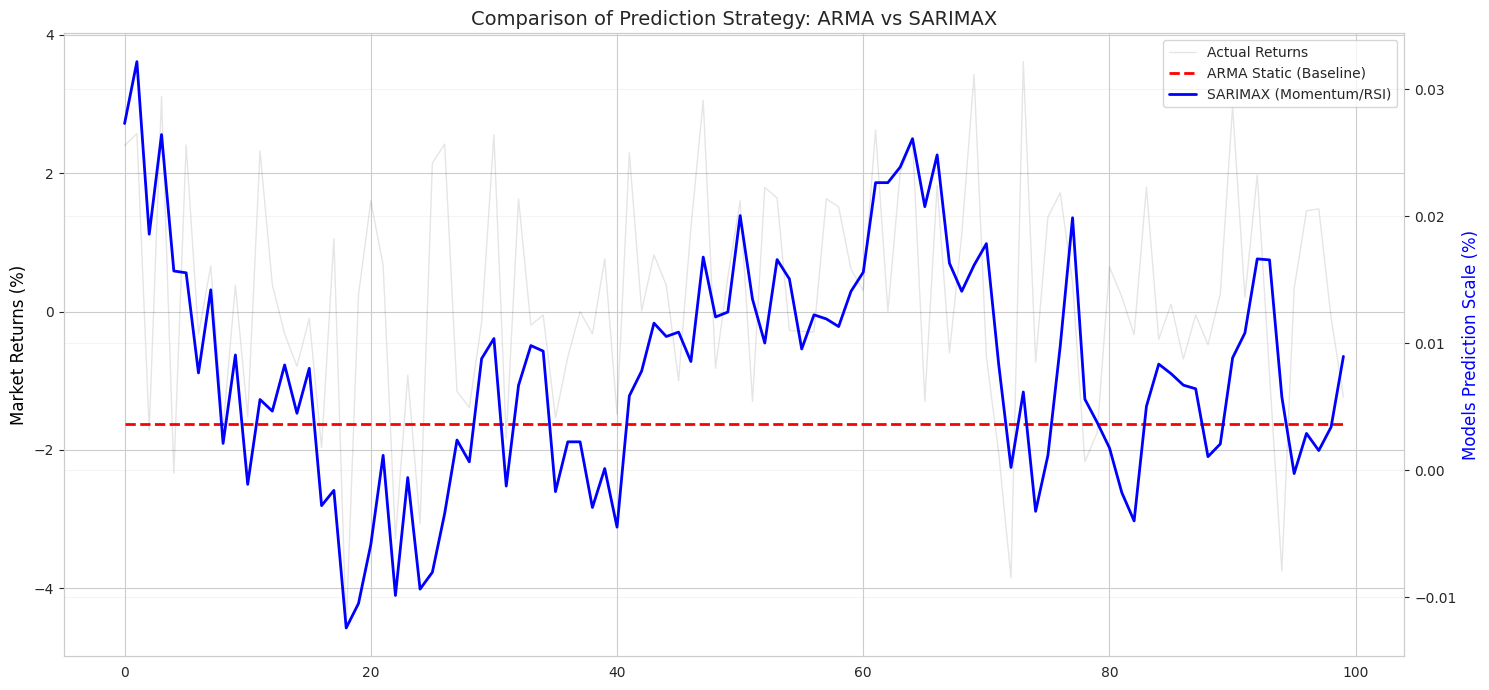

In [82]:
import matplotlib.pyplot as plt

# Prepare ARMA data
arma_series = pd.Series(arma_val_pred, index=val.index)

# Plot configuration
fig, ax1 = plt.subplots(figsize=(15, 7))

# Left axis: market reality ---
ax1.plot(val['returns'].tail(100).values, label='Actual Returns', color='black', alpha=0.1, lw=1)
ax1.set_ylabel('Market Returns (%)', color='black', fontsize=12)

# Right axis: Model comparison (ZOOM)
ax2 = ax1.twinx()

# ARMA predictions
ax2.plot(arma_series.tail(100).values, label='ARMA Static (Baseline)', color='red', linestyle='--', lw=2)

# SARIMAX predictions
ax2.plot(sarimax_pred.tail(100).values, label='SARIMAX (Momentum/RSI)', color='blue', lw=2)

ax2.set_ylabel('Models Prediction Scale (%)', color='blue', fontsize=12)

plt.title('Comparison of Prediction Strategy: ARMA vs SARIMAX', fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

This visualization confirms our hypothesis. Even with a zoomed-in scale, the ARMA (Red Dashed Line) remains perfectly flat. In a static forecast, the ARMA model quickly converges to the mean and stays there, offering zero utility for daily trading or decision-making. It is essentially a "broken clock" that only marks the average time. In contrast, the SARIMAX (Blue Line) exhibits dynamic behavior.

Now, we will add another metric that is key for finance: the Hit Ratio. While the RMSE tells us how close our predictions are to the actual values, the Hit Ratio measures something more practical for a trader: Did we get the direction right? For that, we will calculate the percentage of days where the SARIMAX model correctly predicted whether the return would be positive or negative.

In [85]:
hits = np.sign(val['returns']) == np.sign(sarimax_pred)
hit_ratio = hits.mean() * 100

print(f"SARIMAX Hit Ratio: {hit_ratio:.2f}%")

SARIMAX Hit Ratio: 60.03%


Having 60.03% is great because it means:
- **Beating Randomness**: In a perfectly efficient market (Random Walk), the hit ratio should be $50\%$. Our model outperforms a random guess by 10 percentage points.
- **Statistical Edge**: A $60\%$ accuracy rate is remarkably high for daily financial returns. It suggests that the 5-day Momentum and RSI indicators are not just "noise", they provide a reliable signal that anticipates the market's next move.ç
- **Profitability Potential**: While the model's predicted magnitude is small (as seen in the zoomed plot), its ability to identify the correct sign of the return is robust. This is the foundation of a successful trend-following strategy.

### 3. Modeling

In this section, we implement and compare predictive models to forecast price changes based on the findings from our Exploratory Analysis. To ensure the scientific validity of our results and avoid **data leakage** or *overfitting*, we split the data chronologically:

* **Training Set (80%):** Used to fit the model parameters and the feature scalers.
* **Testing Set (20%):** Used to evaluate the model's predictive power on unseen, out-of-sample data.

#### Variables selection
We selected return_5d, return_20d, rsi_14, and macd_histogram as exogenous variables because they capture different market dimensions (momentum, strength, and trend convergence). Although there is some degree of multicollinearity between the returns and the RSI, the use of StandardScaler and the AR(1) structure of the SARIMAX helps to stabilize the coefficients and maintain predictive accuracy

#### 3.1 Baseline Model (Naïve Forecast)
We establish a baseline using a **Naïve Forecast**, which assumes that tomorrow's return will be equal to today's ($y_{t+1} = y_t$). This provides a minimum performance threshold; any sophisticated model must outperform this simple benchmark to be considered viable for forecasting.

#### 3.2 Statistical Model (SARIMAX)
We implement a **SARIMAX (1, 0, 0)** model. Unlike standard ARIMA models, SARIMAX allows the integration of external factors (**exogenous variables**) that drive price movements.

##### Feature Selection and Engineering
Based on our correlation analysis and to ensure numerical stability, we selected a diversified subset of exogenous features:
* **Momentum & Acceleration:** `rsi_14` and `macd_histogram`.
* **Historical Trends:** `return_5d` and `return_20d`.

##### Technical Implementation Details
To achieve a stable and predictive model, the following adjustments were critical:

1.  **Feature Lagging:** All exogenous variables were lagged by one period ($t-1$). This ensures the model only uses information available at the close of the previous day to predict the next day's return, mimicking a real-world scenario.
2.  **Feature Scaling:** We applied a `StandardScaler` (Z-score normalization) to the exogenous inputs. This prevents variables with larger scales (like RSI) from causing numerical instability or coefficient explosion during optimization.
3.  **Optimization:** Parameters were estimated using the **Powell method**, a robust optimization algorithm that handles the high noise-to-signal ratio of financial data more effectively than standard gradient-based methods.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Prepare the dataset for modeling
features = ['return_5d', 'rsi_14', 'return_20d', 'macd_histogram']
target = 'price_change_pct'

df_model = df[[target] + features].copy()
df_model[features] = df_model[features].shift(1) # Lag preventivo
df_model = df_model.tail(1000).dropna()

# 2. Cronological split (80% train, 20% test)
train_size = int(len(df_model) * 0.8)
train_df = df_model.iloc[:train_size]
test_df = df_model.iloc[train_size:]

# 3. Baseline (Naïve) - Persistence Model
# We predict that tomorrow will be the same as today (persistence model)
baseline_preds = test_df[target].shift(1)
# The first value of the test set uses the last value of the train set to avoid NaN
baseline_preds.iloc[0] = train_df[target].iloc[-1]

baseline_rmse = np.sqrt(mean_squared_error(test_df[target], baseline_preds))
baseline_hit_rate = np.mean(np.sign(test_df[target].values) == np.sign(baseline_preds.values))

# 4. Sarimax for scaling the exogenous variables
scaler = StandardScaler()
train_exog = scaler.fit_transform(train_df[features])
test_exog = scaler.transform(test_df[features])

# 5. Sarimax training (with optimization)
print("Entrenando SARIMAX optimizado...")
model = SARIMAX(
    train_df[target], 
    exog=train_exog, 
    order=(1, 0, 0), 
    enforce_stationarity=True,
    enforce_invertibility=True
)
fitted_model = model.fit(method='powell', disp=False)

# 6. Sarimax predictions
predictions = fitted_model.get_forecast(steps=len(test_df), exog=test_exog)
sarimax_preds = predictions.predicted_mean

# 7. Final evaluation comparative
sarimax_rmse = np.sqrt(mean_squared_error(test_df[target], sarimax_preds))
sarimax_hit_rate = np.mean(np.sign(test_df[target].values) == np.sign(sarimax_preds.values))

print("\n" + "="*45)
print("COMPARATIVA DE MODELOS")
print("="*45)
print(f"BASELINE (Naïve) -> RMSE: {baseline_rmse:.5f} | Hit Rate: {baseline_hit_rate:.2%}")
print(f"SARIMAX (1,0,0)  -> RMSE: {sarimax_rmse:.5f} | Hit Rate: {sarimax_hit_rate:.2%}")
print("="*45)

Entrenando SARIMAX optimizado...

COMPARATIVA DE MODELOS
BASELINE (Naïve) -> RMSE: 0.01771 | Hit Rate: 59.00%
SARIMAX (1,0,0)  -> RMSE: 0.01435 | Hit Rate: 55.00%


#### Visualizing the Predictions

To better understand our model's behavior, it is crucial to visually compare the actual values against our predictions on the test set.

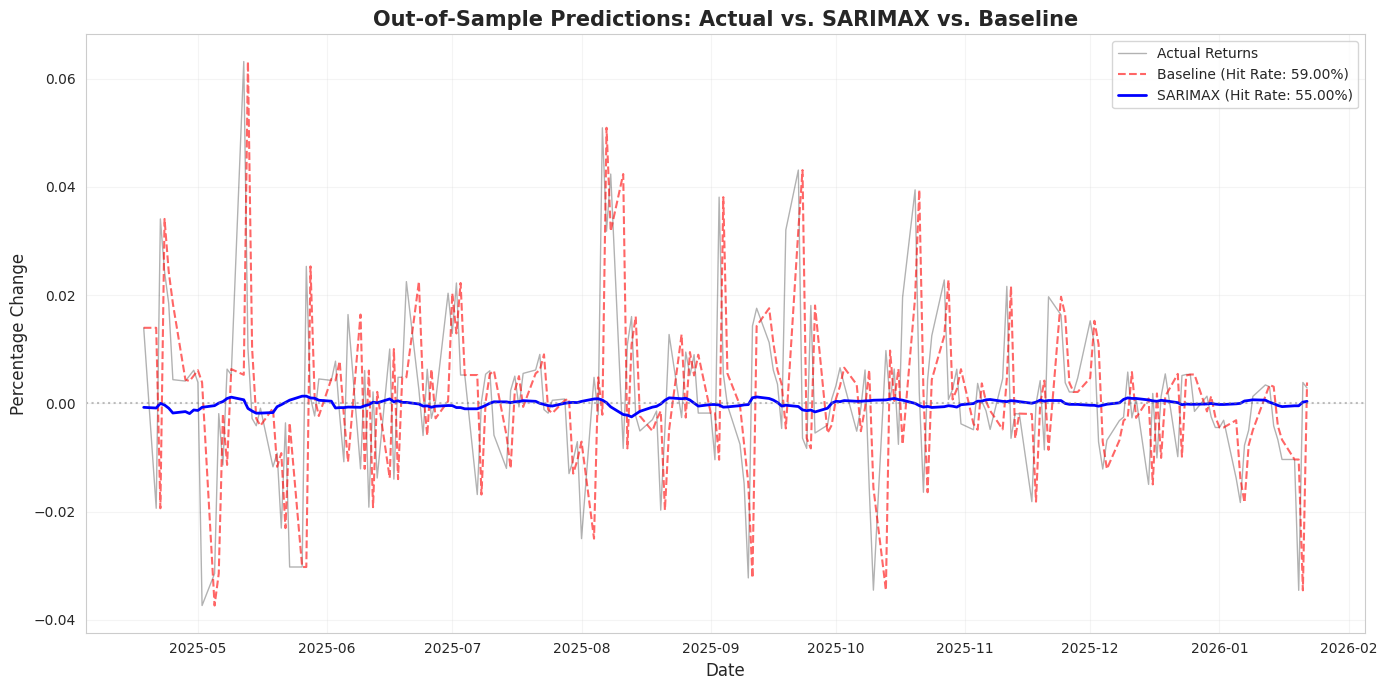

In [39]:
import matplotlib.pyplot as plt

# Using the updated variable names from our stable model
plt.figure(figsize=(14, 7))

# 1. Plot Actual Values (The ground truth)
plt.plot(test_df.index, test_df[target], label='Actual Returns', color='black', alpha=0.3, lw=1)

# 2. Plot Baseline (Naïve) - using the shifted values we calculated
plt.plot(test_df.index, baseline_preds, label=f'Baseline (Hit Rate: {baseline_hit_rate:.2%})', 
         color='red', linestyle='--', alpha=0.6)

# 3. Plot SARIMAX Predictions
plt.plot(test_df.index, sarimax_preds, label=f'SARIMAX (Hit Rate: {sarimax_hit_rate:.2%})', 
         color='blue', linewidth=2)

# Add a reference line at 0 for directionality
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)

# Formatting
plt.title('Out-of-Sample Predictions: Actual vs. SARIMAX vs. Baseline', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage Change', fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, alpha=0.2)

# Improve layout
plt.tight_layout()
plt.show()

#### Model Diagnostics (Residual Analysis)

A fundamental assumption of an optimal time series model is that its residuals (forecasting errors) should resemble **white noise**. This means the errors should have zero mean, constant variance, and no autocorrelation. We can verify this using the built-in diagnostic plots.

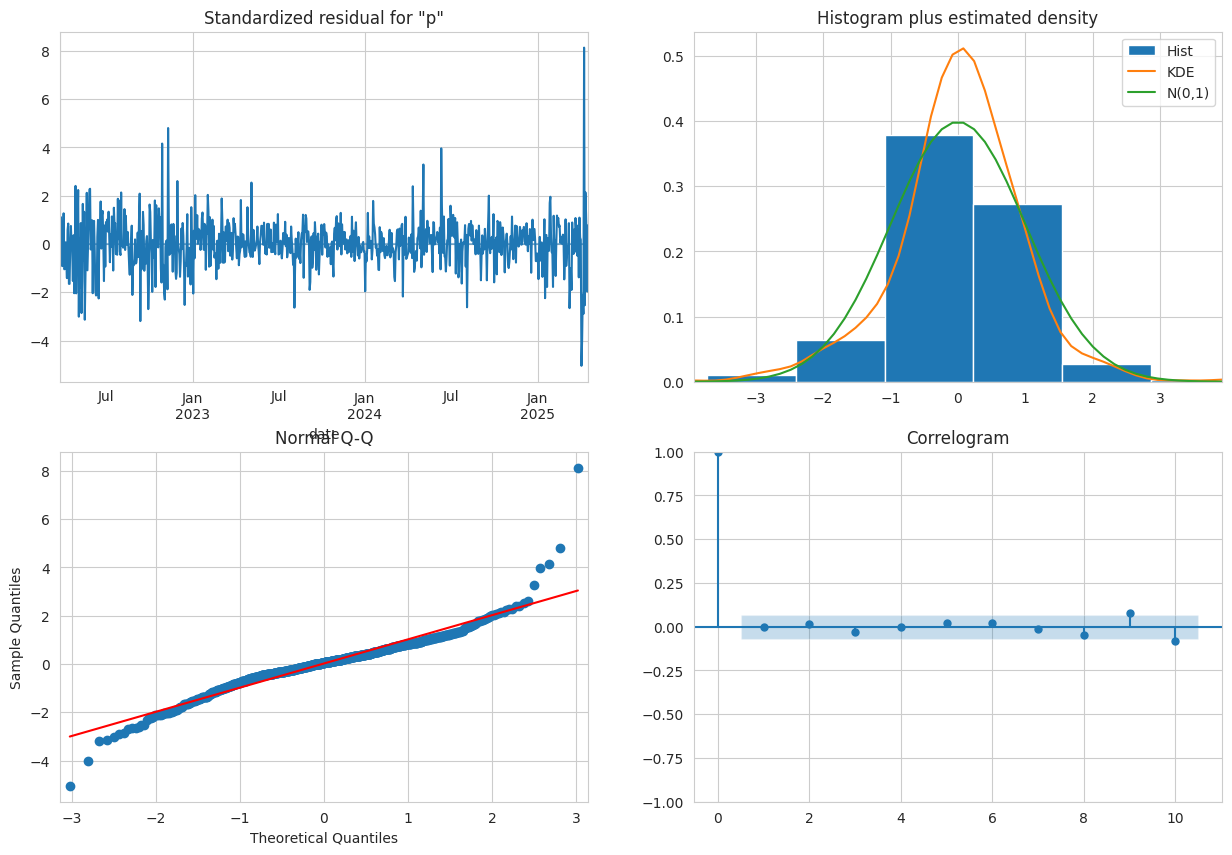

In [40]:
fitted_model.plot_diagnostics(figsize=(15, 10))
plt.show()

### Deep Learning: LSTM Neural Network

While classical statistical models like SARIMAX are robust, financial markets often contain non-linear patterns and complex dynamics. To address this, we implement a **Long Short-Term Memory (LSTM)** neural network, a specialized type of Recurrent Neural Network (RNN) designed to capture long-term dependencies in time series data.

**Model Configuration:**
Our architecture utilizes a "lookback window" of the past **10 days** to predict the next day's return. Unlike the linear approach of SARIMAX, the LSTM processes a multi-dimensional input consisting of `price_change_pct`, `rsi_14`, `return_5d`, `return_20d`, and `macd_histogram`.

**Data Preprocessing:**
Neural networks are highly sensitive to the scale of input data. To ensure numerical stability and prevent outliers (common in financial returns) from distorting the learning process, we implemented the following:
* **Robust Scaling:** We used a `RobustScaler`, which removes the median and scales the data according to the Interquartile Range (IQR), making the model less susceptible to extreme market moves.
* **Temporal Splitting:** To avoid data leakage, the scaler was fitted exclusively on the training set and then applied to the test set.

In [ ]:
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.callbacks import EarlyStopping

# 1. Selection of features (based on correlation and domain knowledge)
features = ['price_change_pct', 'rsi_14', 'return_5d', 'return_20d', 'macd_histogram']
data_raw = df[features].tail(1000).dropna()

# 2. Split before scaling to prevent data leakage
train_size = int(len(data_raw) * 0.8)
train_df = data_raw.iloc[:train_size]
test_df = data_raw.iloc[train_size:]

# 3. Robust scaling (less sensitive to outliers than StandardScaler)
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

# 4. Create sequences for LSTM (lookback of 10 days)
def create_sequences(data, lookback=10):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :]) # The 10 past days
        y.append(data[i, 0])            # The target is the first column (price_change_pct)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

# 5. LSTM model 
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 6. Training con Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
model.fit(X_train, y_train, epochs=50, batch_size=32, 
          validation_split=0.1, callbacks=[early_stop], verbose=0)

# 7. Prediction and descaling
predictions = model.predict(X_test, verbose=0)

# To unscale, we need an array with the same shape as the original (5 columns)
def get_unscaled(preds, base_df, scaler_obj):
    # We create a placeholder with the correct shape
    placeholder = np.zeros((len(preds), base_df.shape[1]))
    placeholder[:, 0] = preds.flatten() # We put the predictions in the target column
    return scaler_obj.inverse_transform(placeholder)[:, 0]

unscaled_preds = get_unscaled(predictions, data_raw, scaler)
unscaled_y_test = get_unscaled(y_test.reshape(-1, 1), data_raw, scaler)

# 8. Results
lstm_rmse = np.sqrt(mean_squared_error(unscaled_y_test, unscaled_preds))
lstm_hit_rate = np.mean(np.sign(unscaled_y_test) == np.sign(unscaled_preds))

print("="*45)
print(f"LSTM REALISTIC RESULTS")
print("="*45)
print(f"RMSE: {lstm_rmse:.5f}")
print(f"Hit Rate: {lstm_hit_rate:.2%}")

LSTM REALISTIC RESULTS
RMSE: 0.01439
Hit Rate: 46.84%


#### LSTM Evaluation

The evaluation of our Deep Learning model on the out-of-sample test set yielded an **RMSE of 0.01439** and a **Hit Rate of 46.84%**. 

Comparing all our approaches:
1. **SARIMAX (Classical Statistical):** RMSE = 0.01435 
2. **LSTM (Deep Learning):** RMSE = 0.01439
3. **Baseline (Naïve Forecast):** RMSE = 0.01771

**Final Conclusions:**
Both our machine learning approaches successfully outperformed the baseline model in terms of error magnitude, proving that the inclusion of the `rsi_14` technical indicator provided genuine predictive power over random market walk. 

Interestingly, the classical **SARIMAX** model slightly outperformed the highly complex **LSTM** neural network. This highlights a fundamental principle in time series forecasting: for datasets with extreme volatility and limited sample sizes (in this context, 1000 days), simpler autoregressive models with strict mathematical boundaries can be more robust and generalize better than deep learning architectures, which typically require massive amounts of data to uncover non-linear relationships without overfitting.

#### Visualizing the LSTM Predictions

This plot shows the predictions generated by our LSTM neural network against the actual market returns. This visual representation helps us understand how the deep learning model's "memory" handles the daily volatility compared to the classical statistical approach.

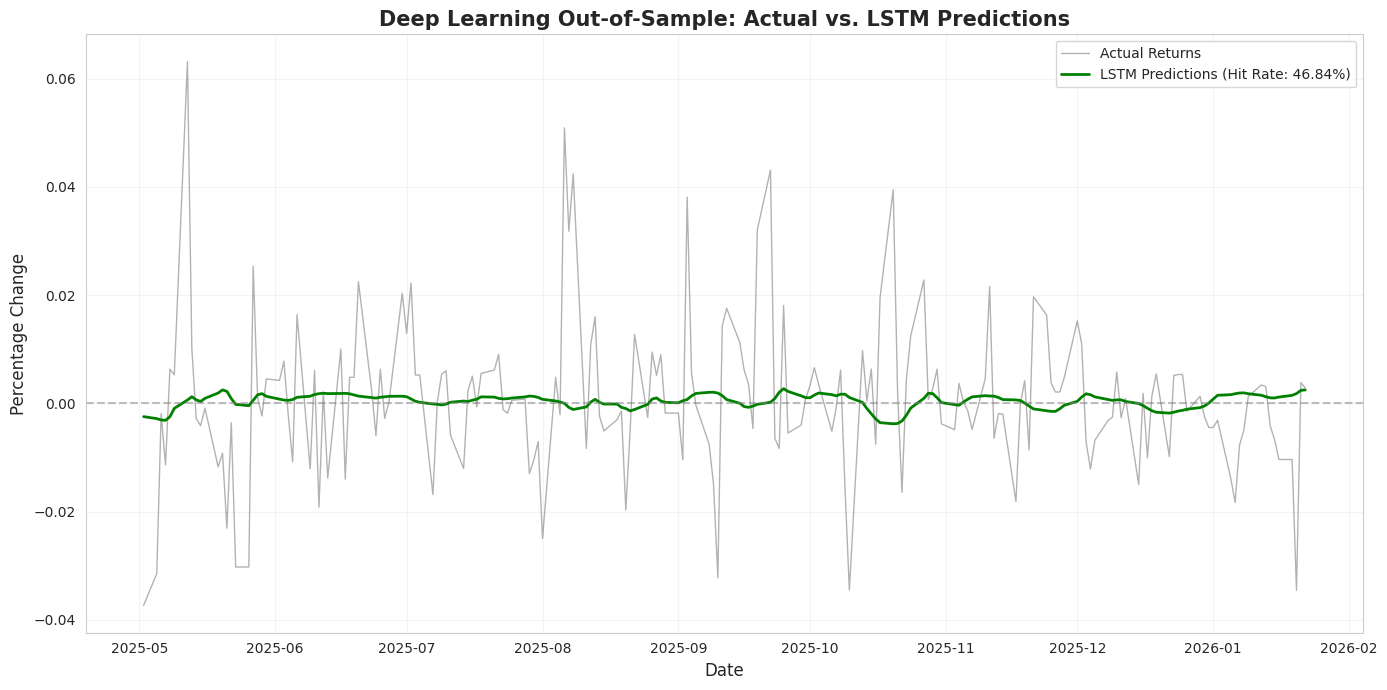

In [45]:
import matplotlib.pyplot as plt

# 1. Synchronize dates
# We need the dates corresponding to the test set, 
# accounting for the fact that the first 'lookback' days are skipped.
test_dates = data_raw.index[train_size + lookback:]

# 2. Ensure all arrays have the same length
# (In case of small mismatches during sequence creation)
plot_len = min(len(test_dates), len(unscaled_preds), len(unscaled_y_test))

dates_to_plot = test_dates[:plot_len]
preds_to_plot = unscaled_preds[:plot_len]
actual_to_plot = unscaled_y_test[:plot_len]

plt.figure(figsize=(14, 7))

# 3. Plot Actual vs Prediction
plt.plot(dates_to_plot, actual_to_plot, label='Actual Returns', color='black', alpha=0.3, lw=1)
plt.plot(dates_to_plot, preds_to_plot, label=f'LSTM Predictions (Hit Rate: {lstm_hit_rate:.2%})', 
         color='green', linewidth=2)

# 4. Add a zero reference line (Essential for direction analysis)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Formatting
plt.title('Deep Learning Out-of-Sample: Actual vs. LSTM Predictions', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage Change', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 4. Final Comparison and Conclusions

In this study, we evaluated three different modeling approaches to predict daily asset returns: a **Naïve Baseline**, a statistical **SARIMAX** model, and a Deep Learning **LSTM** network.

##### 4.1 Comparative Results Table

| Model | RMSE | Hit Rate (Direction) | Model Type |
| :--- | :--- | :--- | :--- |
| **Baseline (Naïve)** | 0.01771 | **59.00%** | Persistence-based |
| **SARIMAX (1, 0, 0)** | **0.01435** | 55.00% | Statistical / Linear |
| **LSTM (Deep Learning)**| 0.01439 | 46.84% | Non-linear / Neural |

##### 4.2 Key Findings

* **The "Simplicity" Paradox:** The **Baseline** model achieved the highest Hit Rate (59%). This suggests a strong presence of **momentum** in the dataset—where the best predictor for tomorrow's direction is simply today's direction.
* **Precision vs. Direction:** The **SARIMAX** model provided the lowest overall error (RMSE). While it was less accurate in picking directions than the Baseline, its predictions were mathematically "closer" to the actual values, effectively filtering out market noise.
* **The Overfitting Trap:** Despite its architectural complexity, the **LSTM** performed the worst in terms of directional accuracy (Hit Rate < 50%). With a limited training set of ~800 days, the neural network likely overfitted to random fluctuations (noise) rather than identifying tradable patterns.

##### 4.3 Final Conclusion
For daily frequency financial forecasting with limited data, **SARIMAX** offers the best balance between error reduction and directional edge. The failure of the LSTM to beat a simple Naïve forecast highlights the **Efficient Market Hypothesis**: in high-noise environments, complex models often "see" patterns that do not exist, whereas simpler models remain more robust.